In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
df=pd.read_csv("cleaned_vm_data.csv")

In [3]:
unique_vms = df.drop_duplicates(subset=["API Name"])
count = len(unique_vms)
print(count)

943


In [4]:
filtered_df = df[df['API Name'].isin(['t2.small', 't2.medium', 't2.xlarge', 't2.2xlarge'])]


In [6]:
filtered_df.to_csv("filtered_vm4_data.csv", index=False) 

In [8]:
df=pd.read_csv("CPRS-wise-reliability-99-costs.csv")

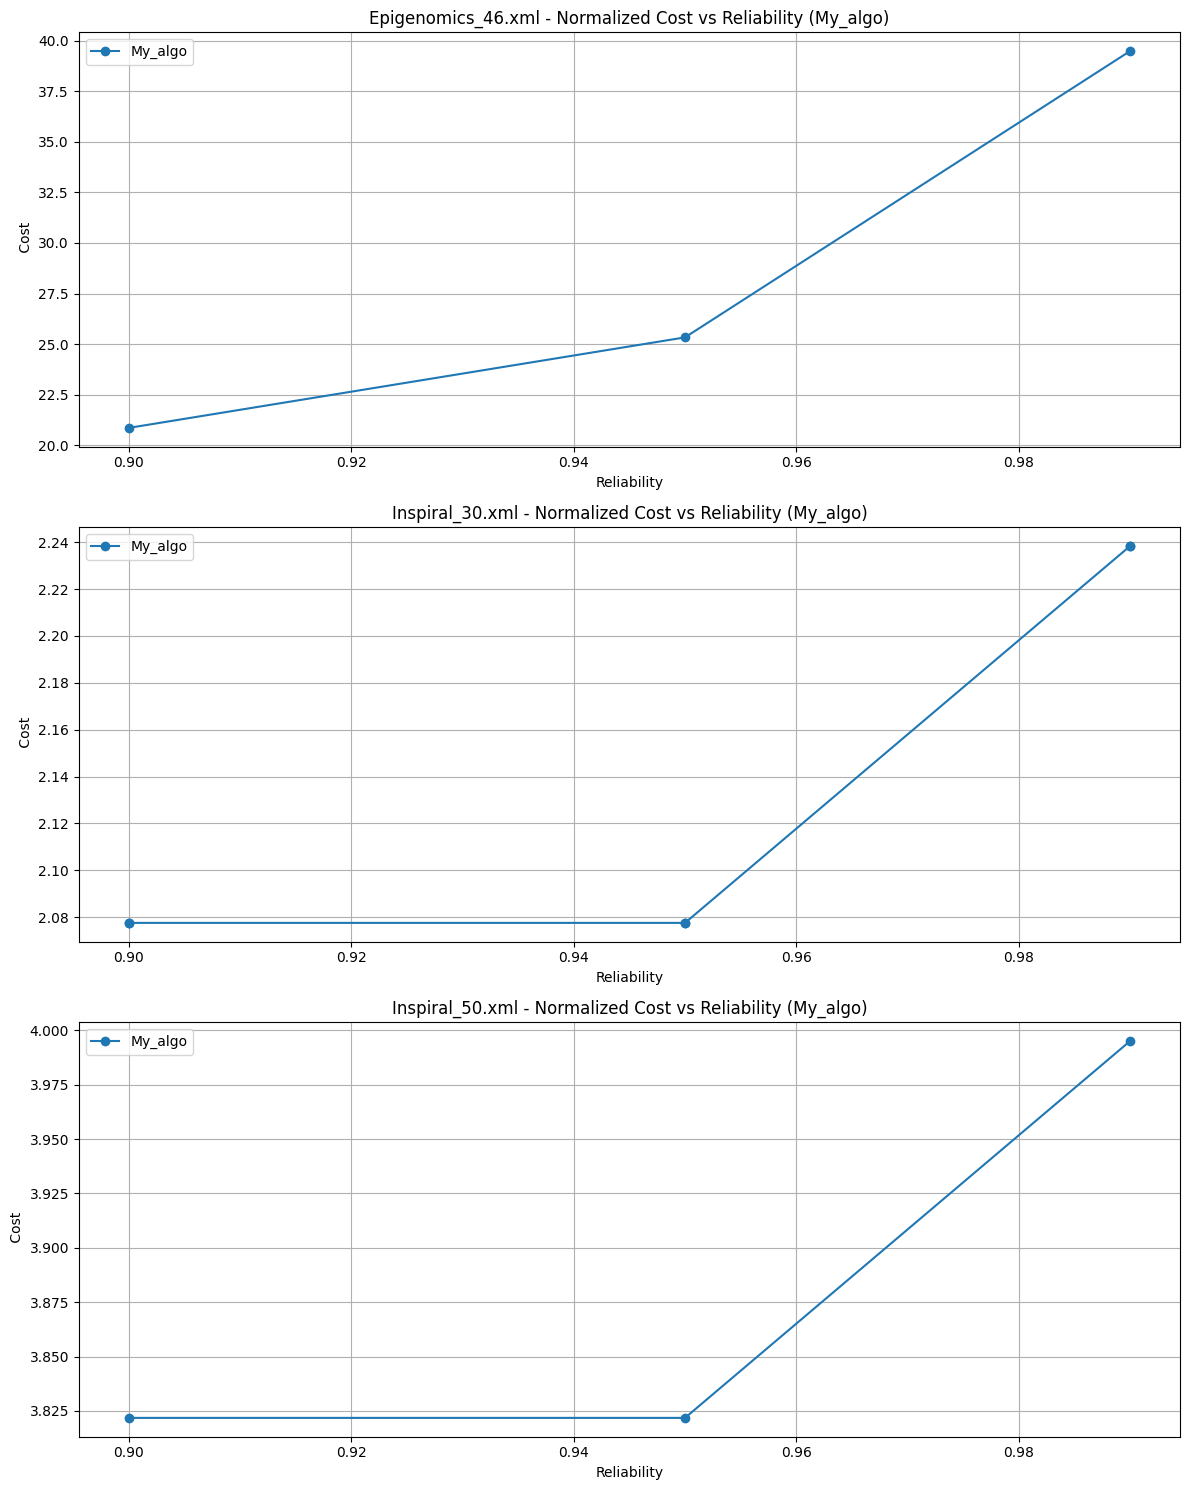

In [16]:
# Read the dataset
df_my = pd.read_csv("CPRS-wise-reliability-99-costs.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Reliability"] = df_my["Reliability"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {"Montage_50.xml", "CyberShake_30.xml"}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Reliability")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / 1

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Reliability"], frac=0.5)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Reliability (My_algo)")
    ax.set_xlabel("Reliability")
    ax.set_ylabel(" Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

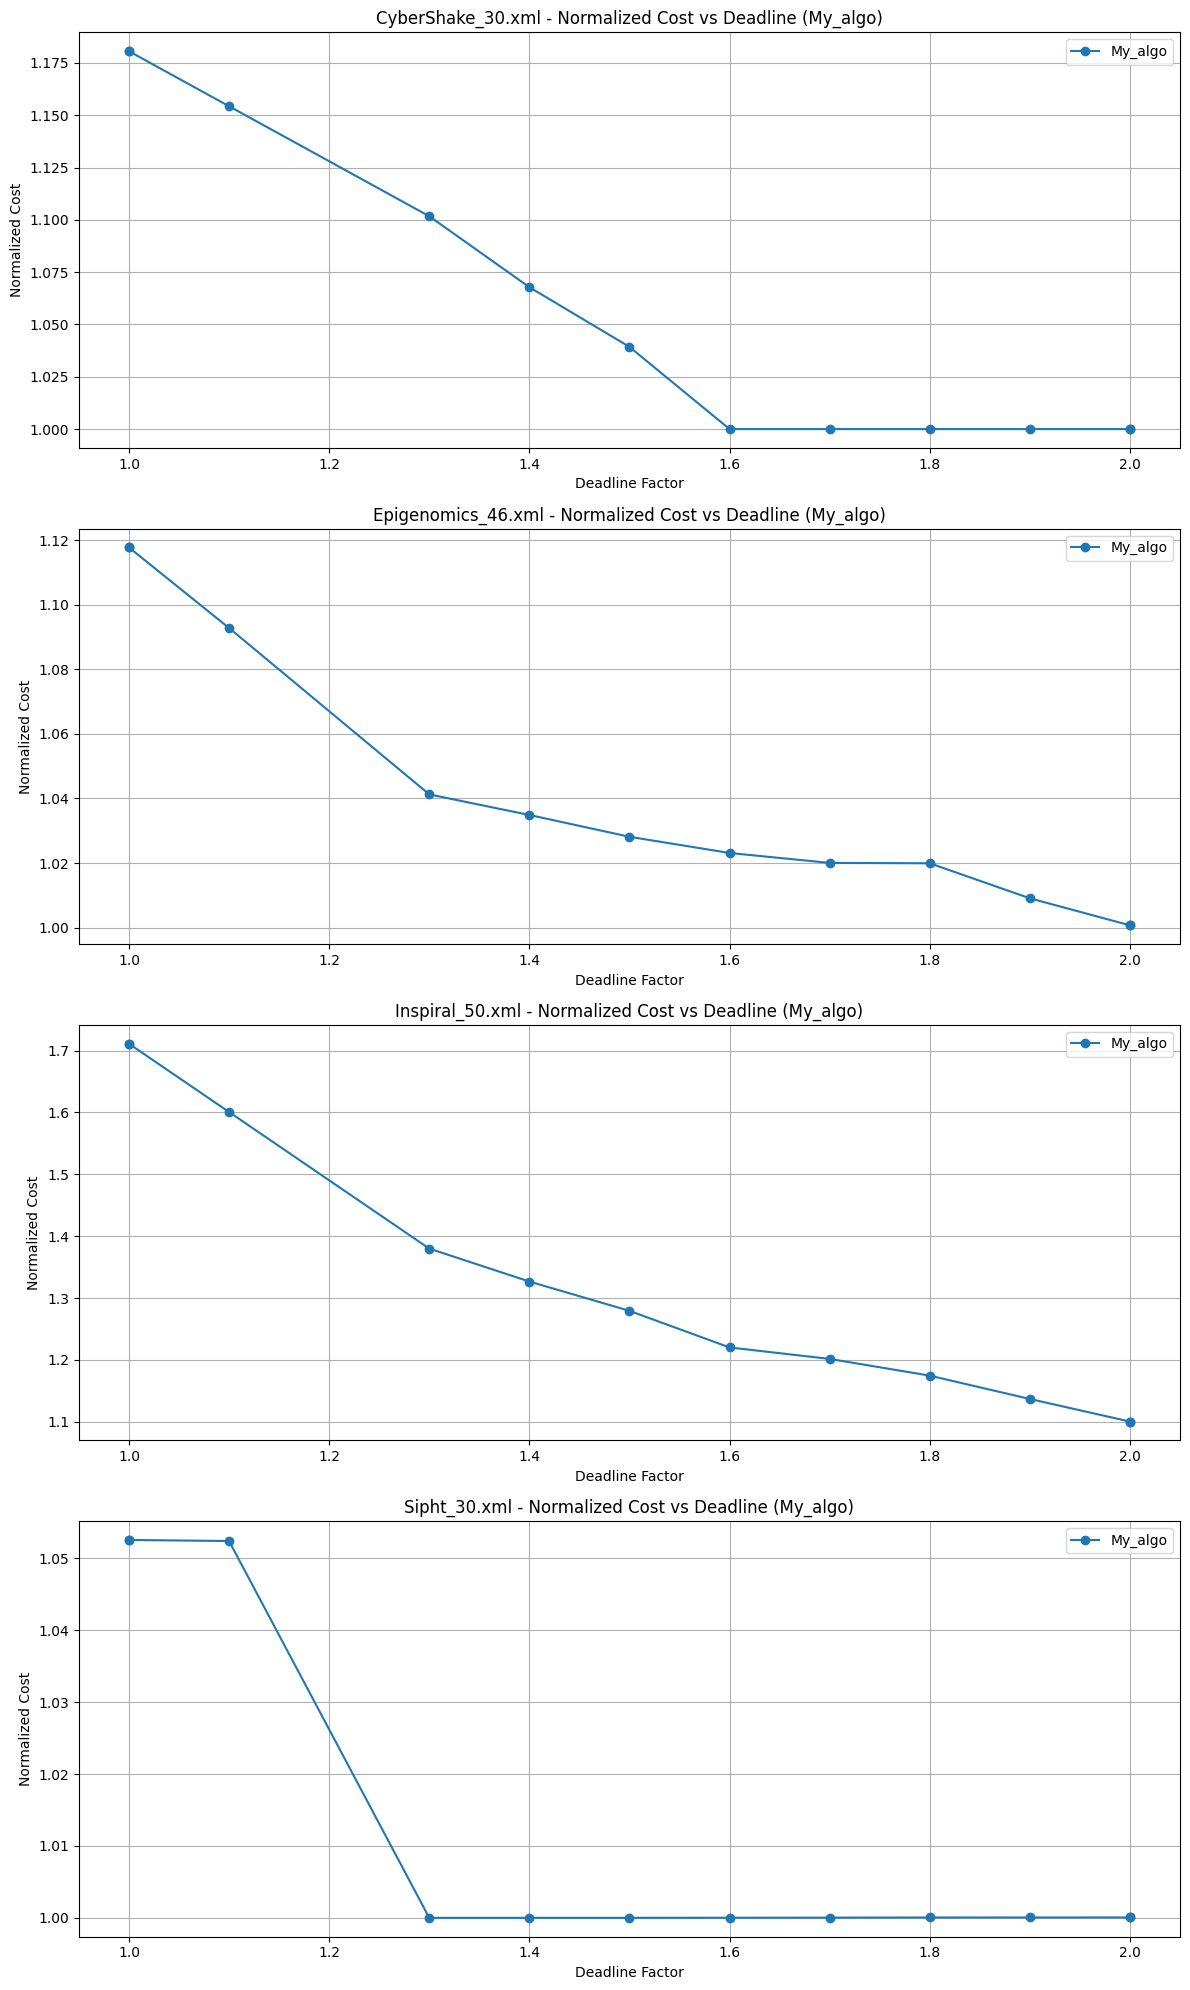

In [10]:
# Read the dataset
df_my = pd.read_csv("workflow-wise-costs-99-Legrange_v2.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {"Montage_50.xml", "Inspiral_30.xml"}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Deadline")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / min_my

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Deadline"], frac=0.5)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline (My_algo)")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

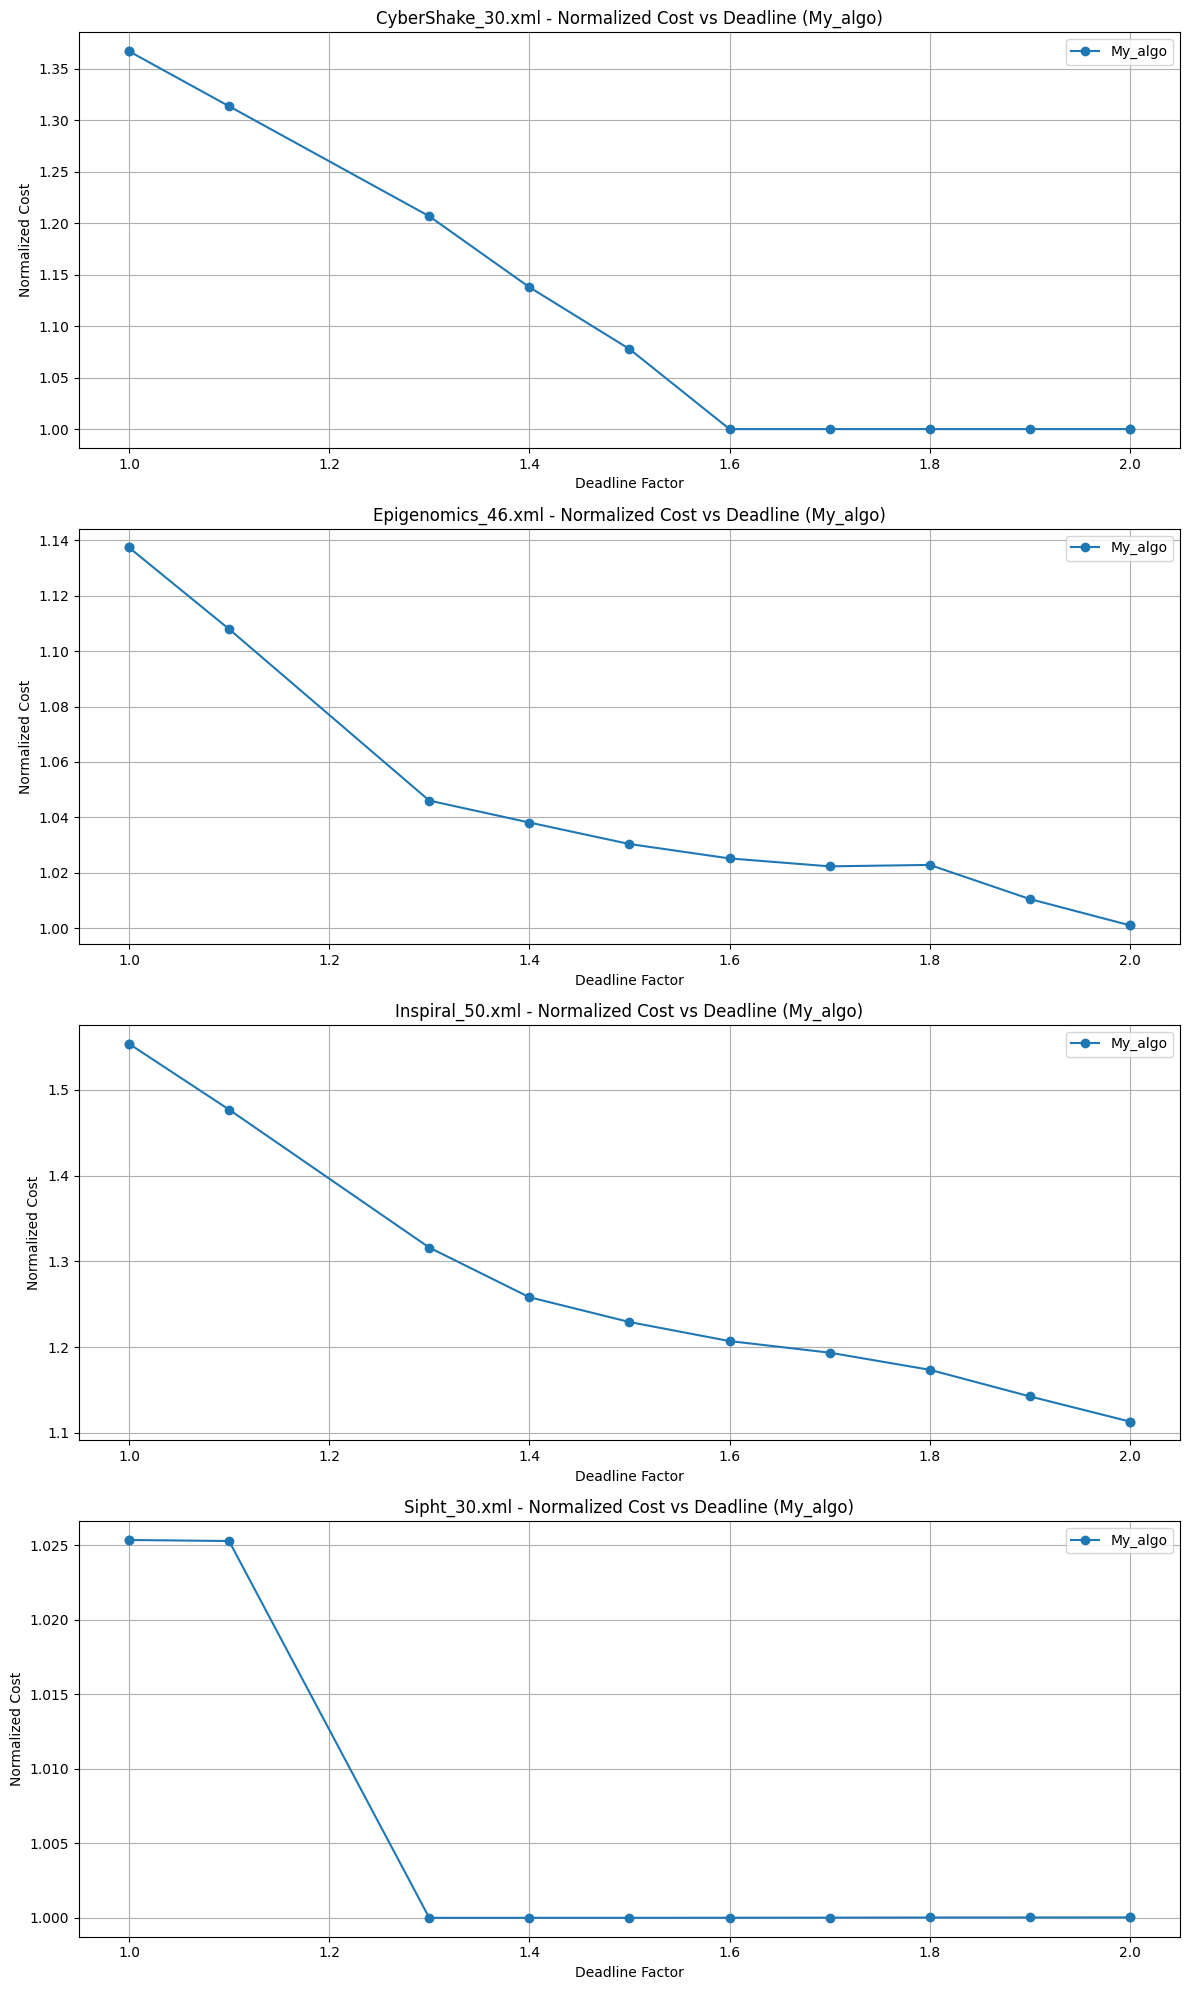

In [11]:
# Read the dataset
df_my = pd.read_csv("workflow-wise-costs-95-Legrange_v2.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {"Montage_50.xml", "Inspiral_30.xml"}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Deadline")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / min_my

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Deadline"], frac=0.5)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline (My_algo)")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

In [3]:


# Read the datasets
df_my = pd.read_csv("workflow-wise-costs-95-Legrange_v2.csv")
df_PLS = pd.read_csv("workflow-wise-costs-99-Legrange_v2.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()
df_PLS.columns = df_PLS.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_PLS["Deadline"] = df_PLS["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()
df_PLS["Workflow"] = df_PLS["Workflow"].str.strip()

# Merge
merged_df = pd.merge(
    df_my,
    df_PLS,
    on=["Workflow", "Deadline"],
    suffixes=("_My", "_PLS")
)

# Exclude workflows
excluded_workflows = {"Montage_50.xml","Sipht_30.xml"}
merged_df = merged_df[~merged_df["Workflow"].isin(excluded_workflows)]

# Plot
workflows = merged_df["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = merged_df[merged_df["Workflow"] == workflow].sort_values("Deadline")

    # Normalize costs
    min_my = wf_df["Cost_My"].min()
    min_pls = wf_df["Cost_PLS"].min()
    wf_df["Norm_Feadline"] = wf_df["Cost_My"] / 1
    wf_df["Norm_PLS"] = wf_df["Cost_PLS"] / 1

    # Smooth with LOWESS
    feadline_smoothed = sm.nonparametric.lowess(wf_df["Norm_Feadline"], wf_df["Deadline"], frac=0.6)
    pls_smoothed = sm.nonparametric.lowess(wf_df["Norm_PLS"], wf_df["Deadline"], frac=0.1)

    # Plot
    ax.plot(feadline_smoothed[:, 0], feadline_smoothed[:, 1], label="with 95%", linestyle="-", marker="o")
    ax.plot(pls_smoothed[:, 0], pls_smoothed[:, 1], label="with 99%", linestyle="--", marker="s")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'workflow-wise-costs-95-Legrange_v2.csv'

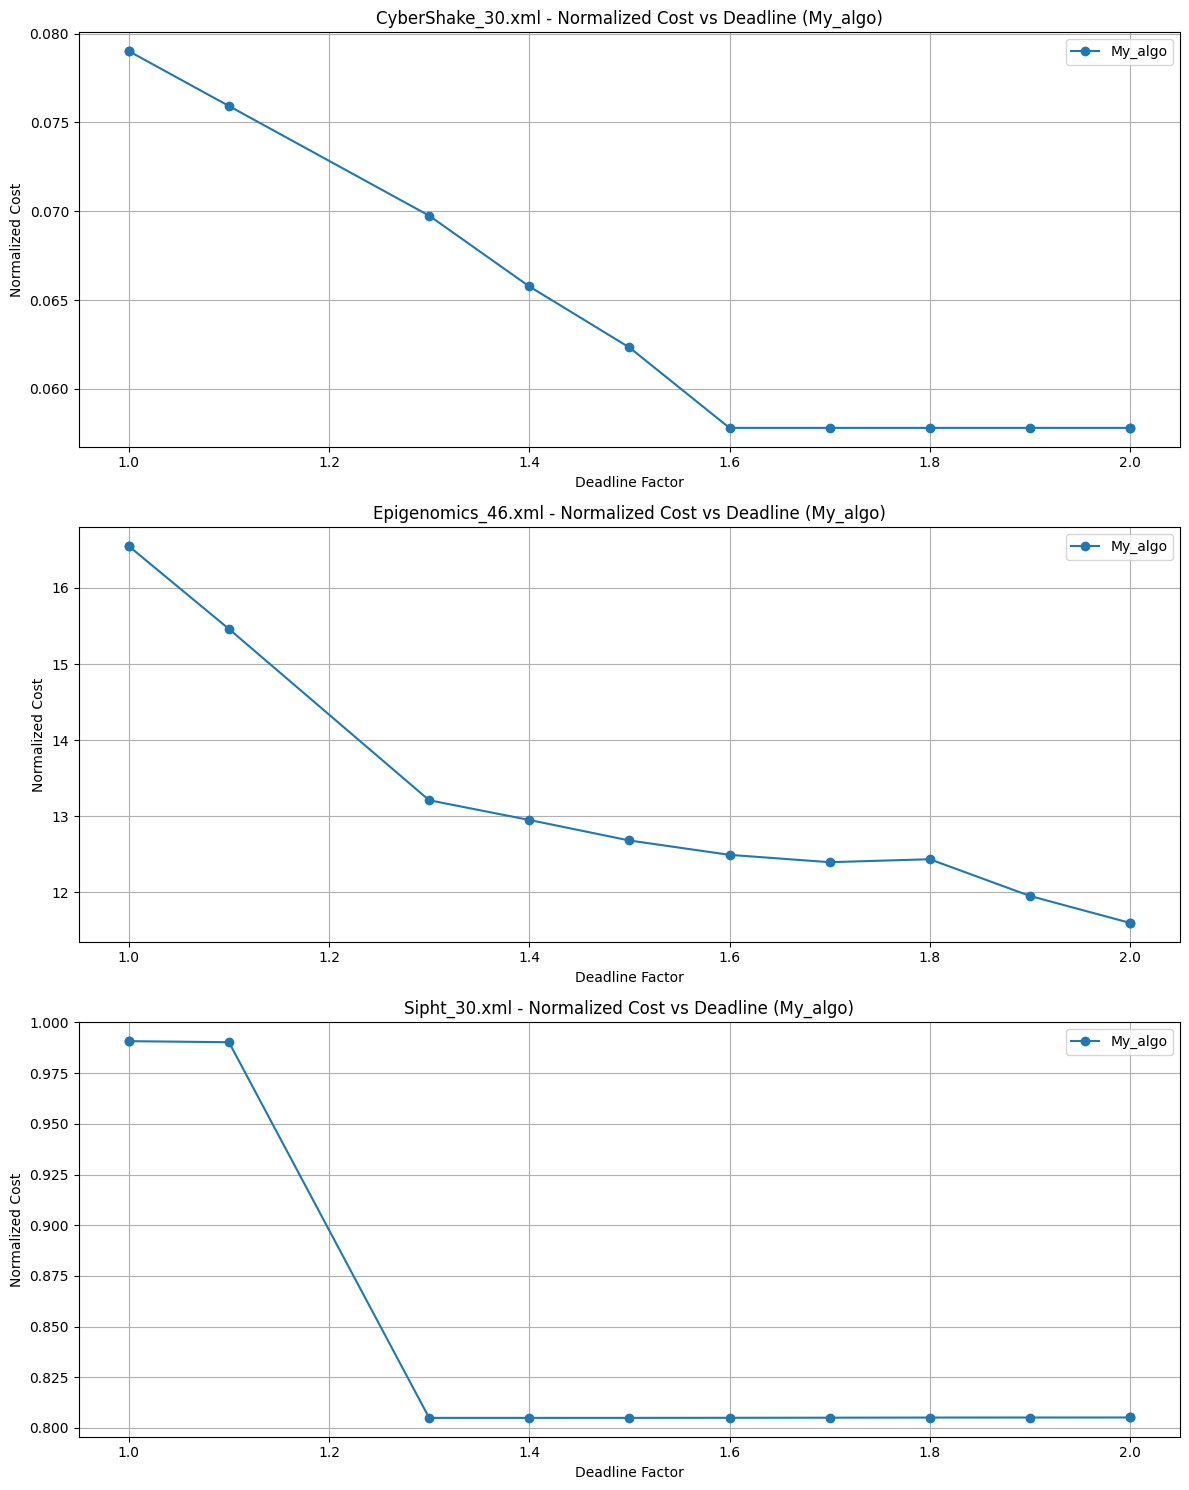

In [14]:
# Read the dataset
df_my = pd.read_csv("workflow-wise-costs-99-Legrange_v2.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {"Montage_50.xml"}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Deadline")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / 1

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Deadline"], frac=0.5)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline (My_algo)")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

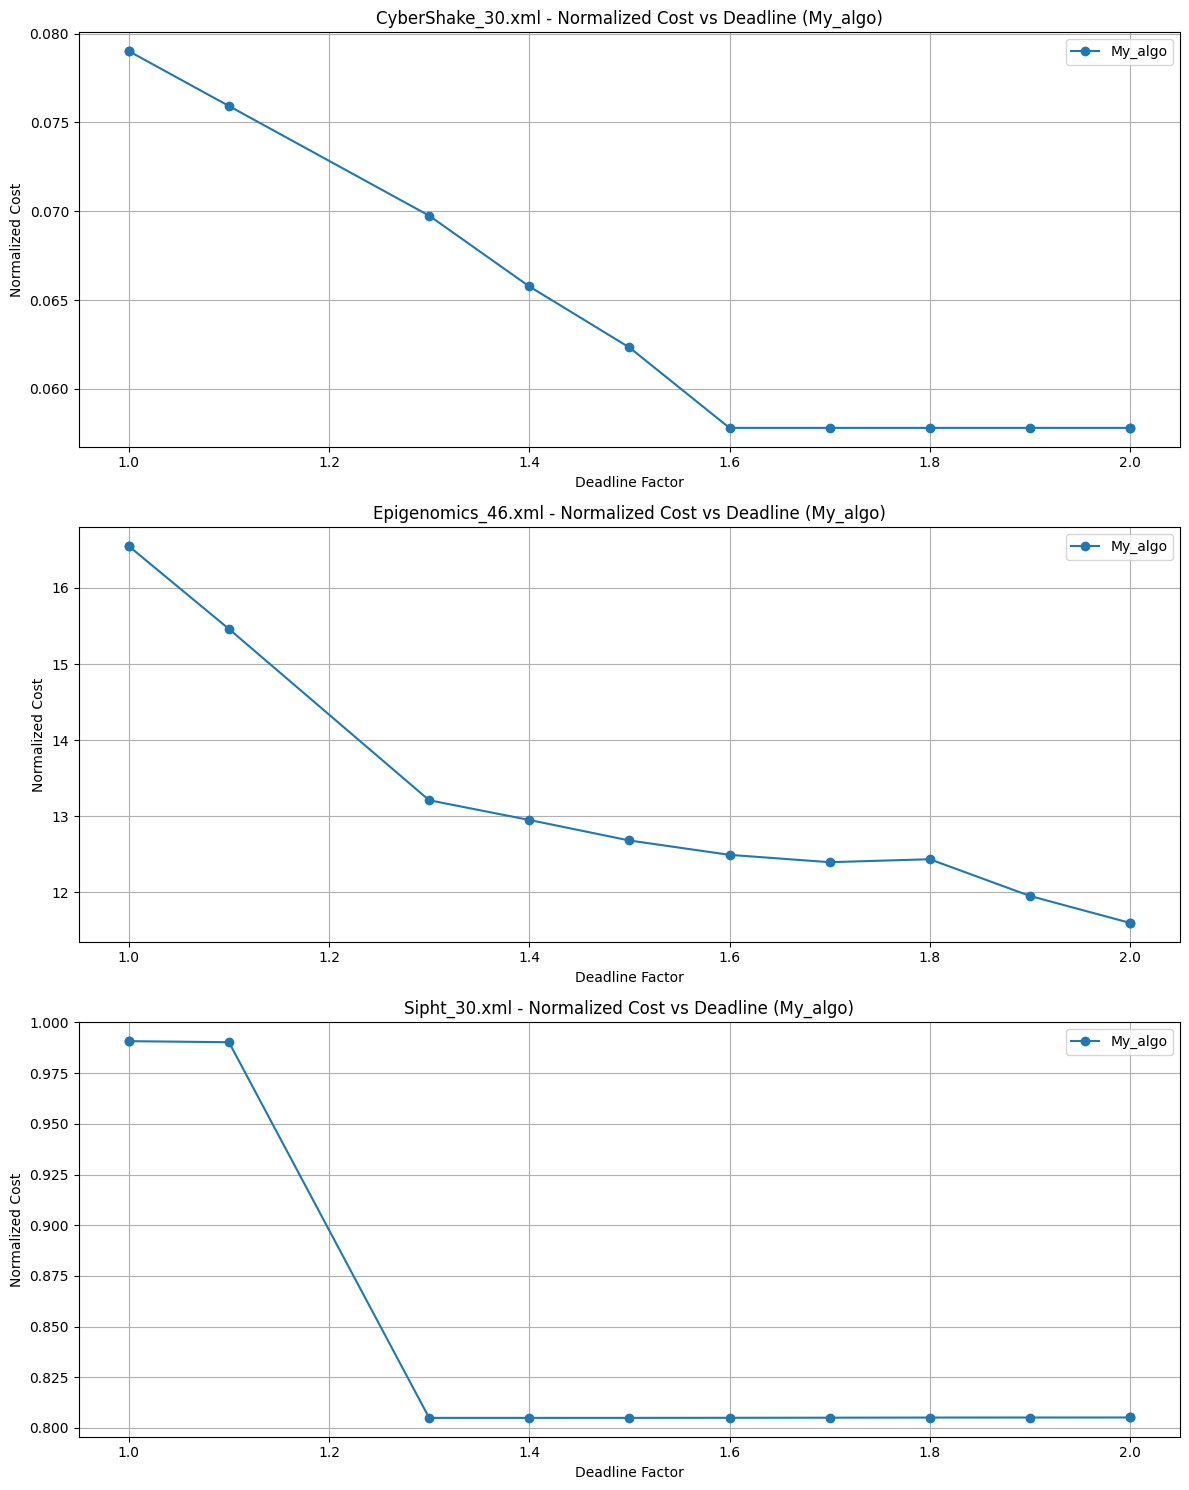

In [15]:
# Read the dataset
df_my = pd.read_csv("workflow-wise-costs-90-Legrange_v2.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {"Montage_50.xml"}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Deadline")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / 1

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Deadline"], frac=0.5)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline (My_algo)")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

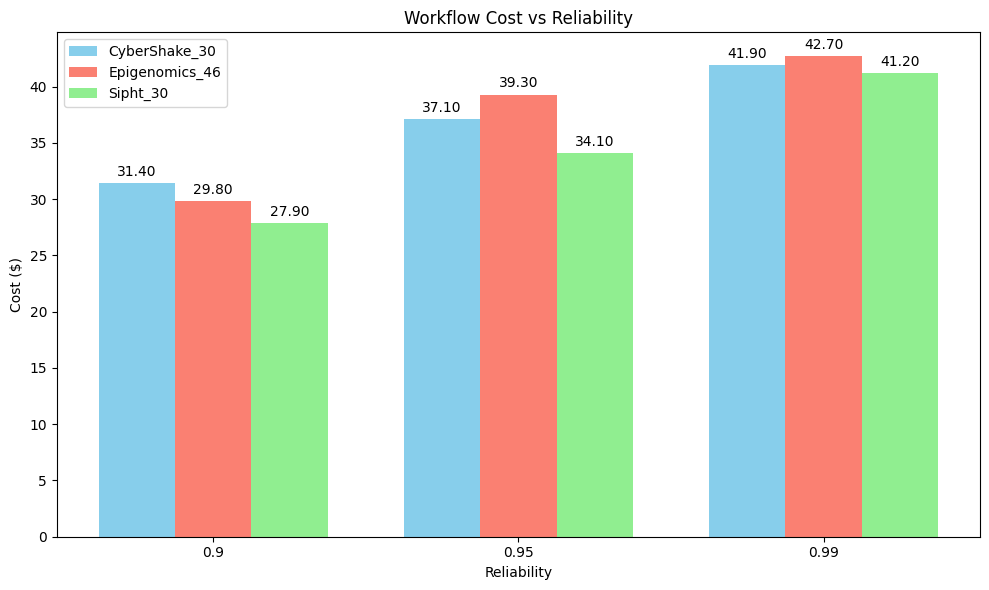

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read CSV
df = pd.read_csv("workflow-reliability.csv")

# Unique values
reliabilities = sorted(df['Reliability'].unique())
workflows = df['Workflow'].unique()

# Width setup
x = np.arange(len(reliabilities))
width = 0.25

# Plot setup
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['skyblue', 'salmon', 'lightgreen']
offsets = [-width, 0, width]

# Plot bars
for i, workflow in enumerate(workflows):
    workflow_data = df[df['Workflow'] == workflow].sort_values(by='Reliability')
    costs = workflow_data['Cost'].values
    bars = ax.bar(x + offsets[i], costs, width, label=workflow, color=colors[i])
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

# Labels and legend
ax.set_xlabel('Reliability')
ax.set_ylabel('Cost ($)')
ax.set_title('Workflow Cost vs Reliability')
ax.set_xticks(x)
ax.set_xticklabels([str(r) for r in reliabilities])
ax.legend()

plt.tight_layout()
plt.show()


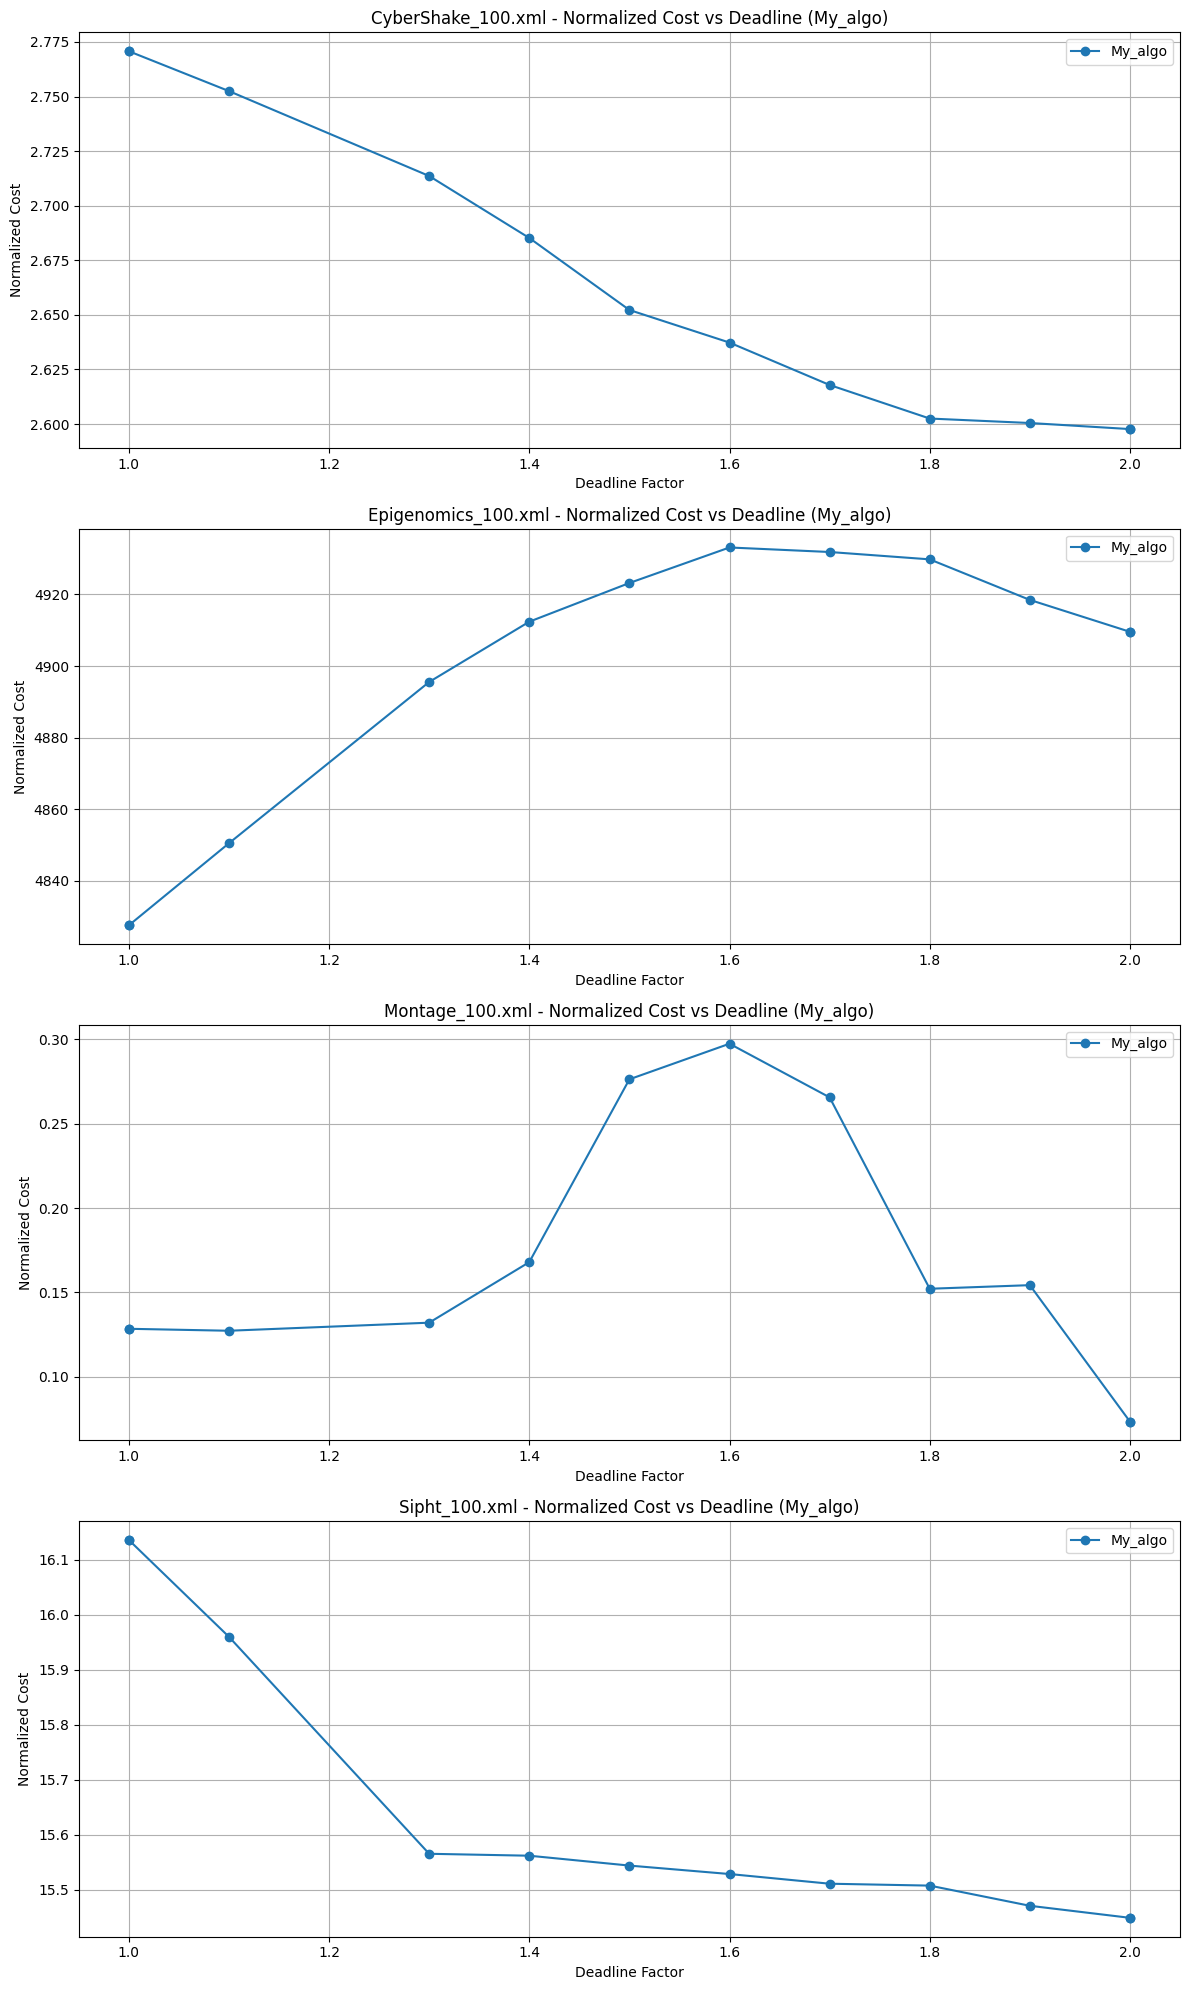

In [15]:
# Read the dataset
df_my = pd.read_csv("workflow-wise-costs-800-Legrange_v2.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {"Montage_50.xml"}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Deadline")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / 1

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Deadline"], frac=0.5)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline (My_algo)")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

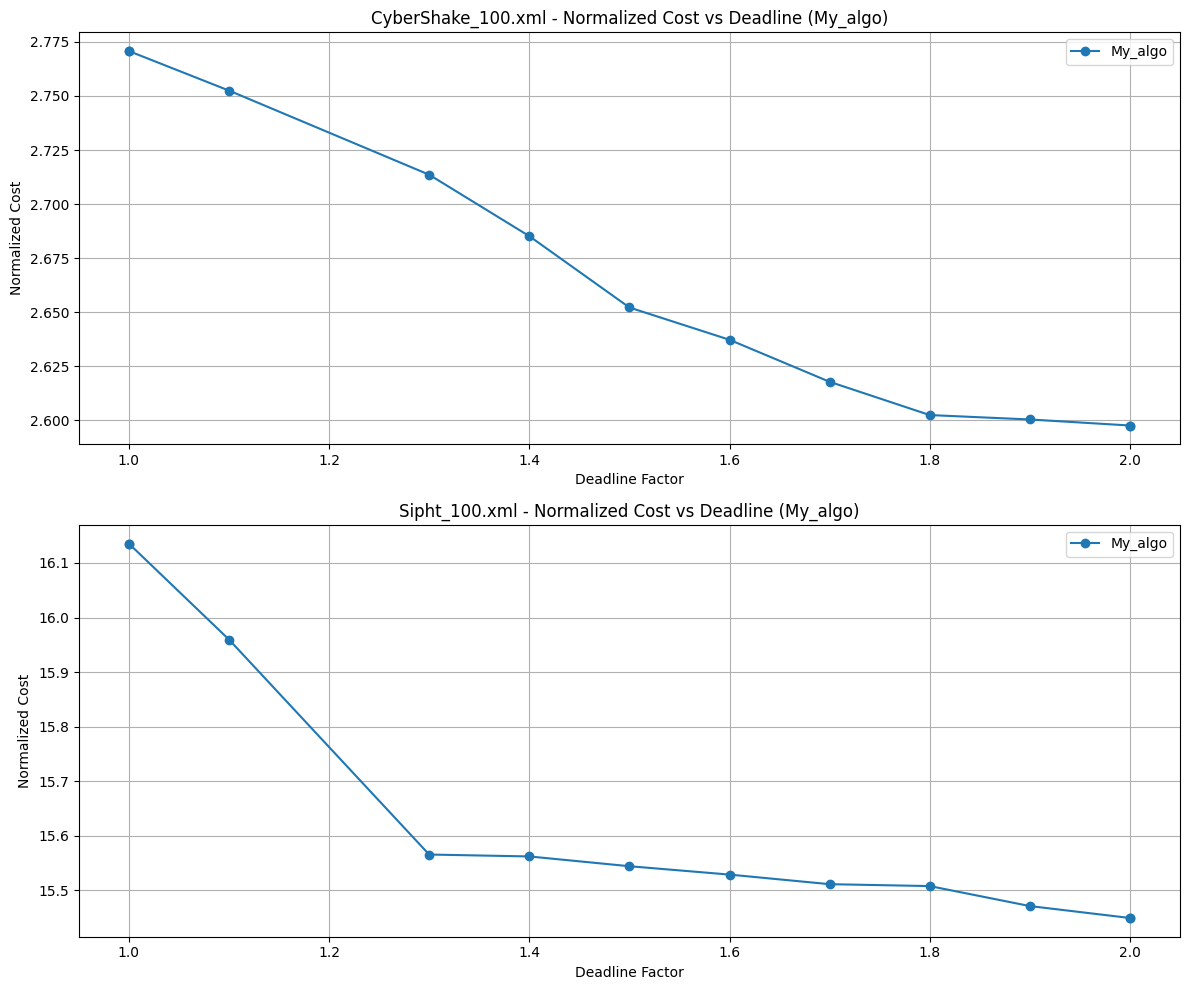

In [17]:
# Read the dataset
df_my = pd.read_csv("workflow-wise-costs-955_100-Legrange_v2.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {"Montage_100.xml","Epigenomics_100.xml"}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Deadline")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / 1

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Deadline"], frac=0.5)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline (My_algo)")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

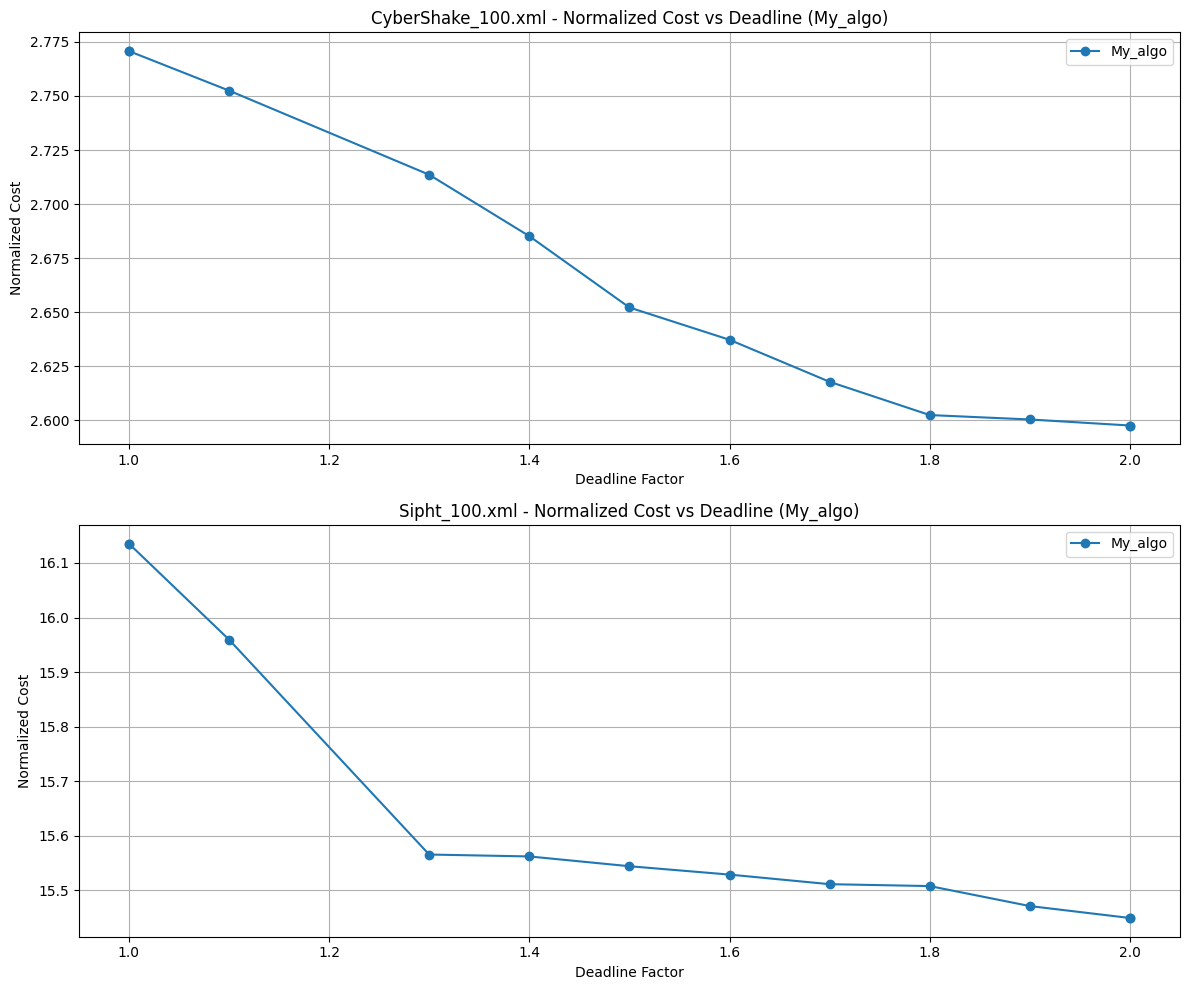

In [18]:
# Read the dataset
df_my = pd.read_csv("workflow-wise-costs-999_100-Legrange_v2.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {"Montage_100.xml","Epigenomics_100.xml"}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Deadline")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / 1

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Deadline"], frac=0.5)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline (My_algo)")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

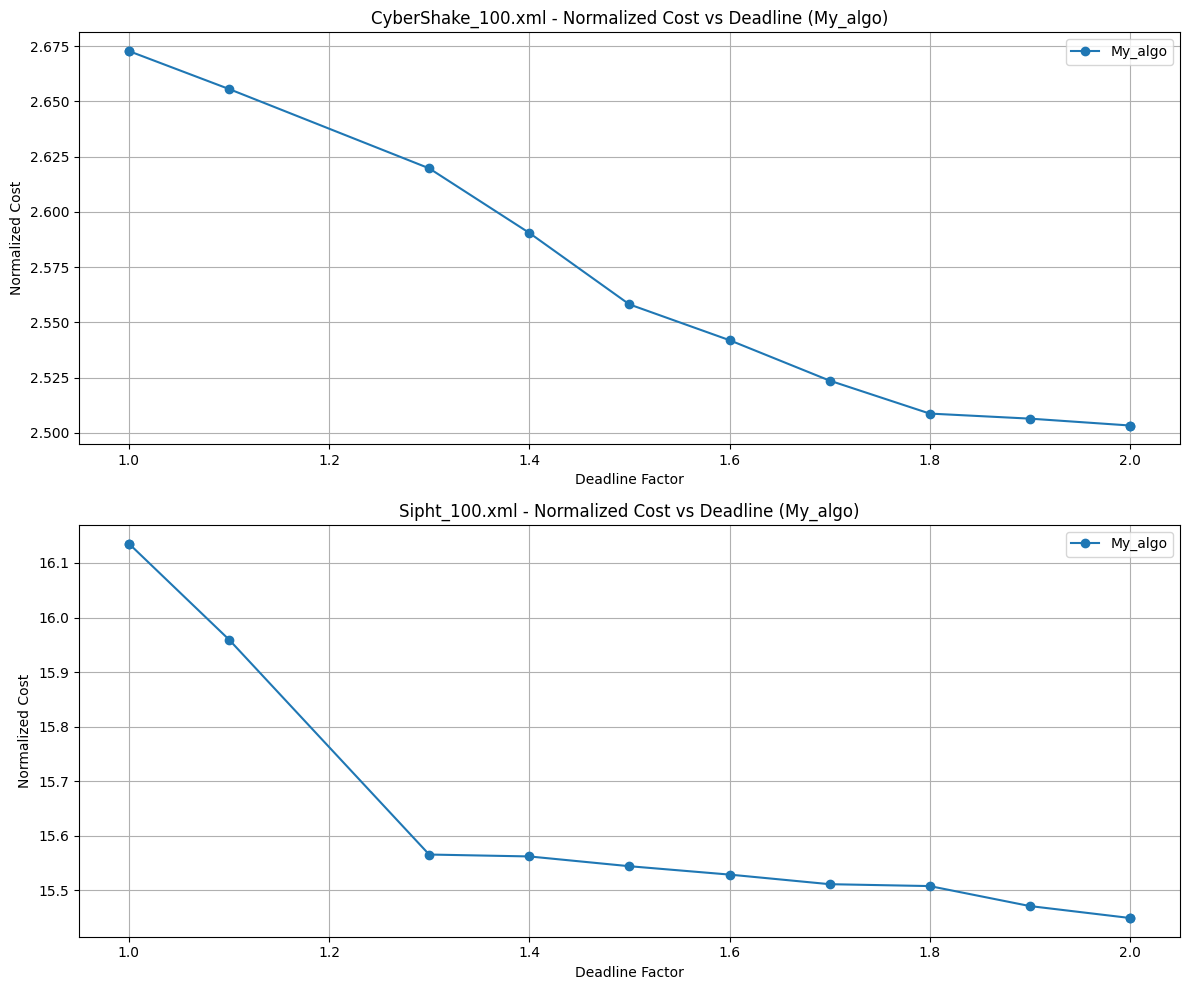

In [19]:
# Read the dataset
df_my = pd.read_csv("workflow-wise-costs-800_100-Legrange_v2.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {"Montage_100.xml","Epigenomics_100.xml"}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Deadline")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / 1

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Deadline"], frac=0.5)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline (My_algo)")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

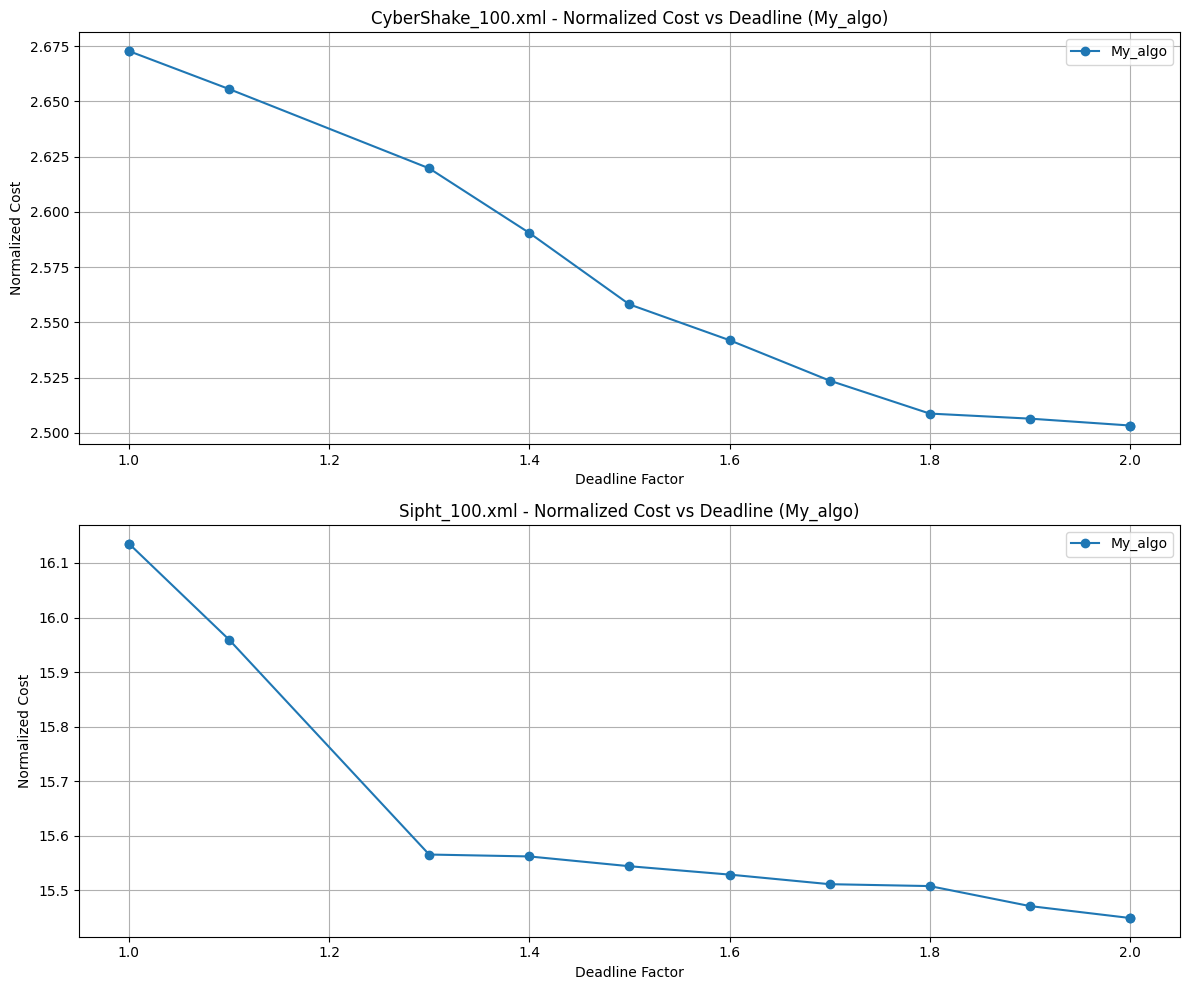

In [ ]:
# Read the dataset
df_my = pd.read_csv("workflow-wise-costs-800_100-Legrange_v2.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {"Montage_100.xml","Epigenomics_100.xml"}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Deadline")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / 1

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Deadline"], frac=0.5)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline (My_algo)")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

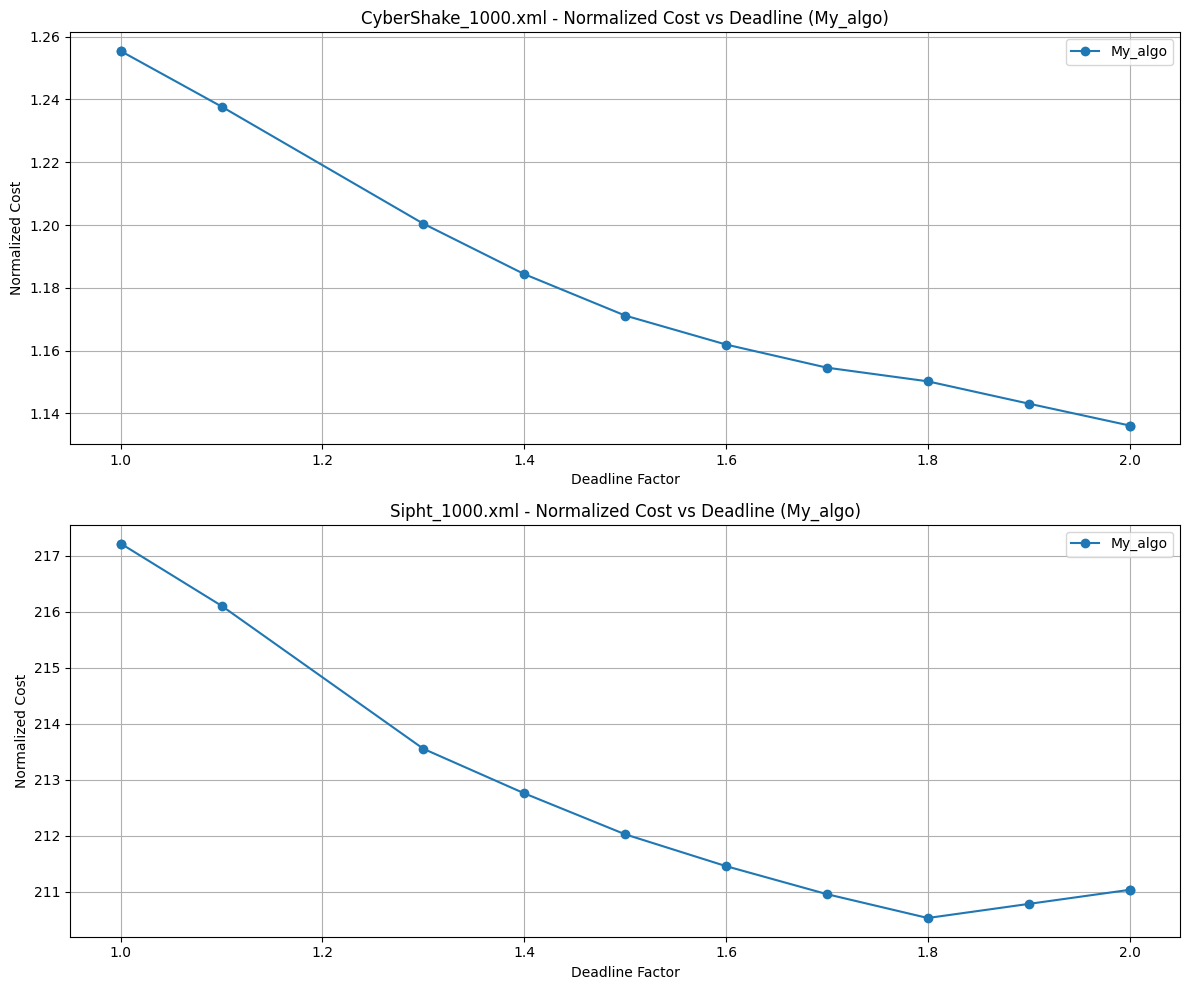

In [21]:
# Read the dataset
df_my = pd.read_csv("workflow-wise-costs-900_1000-Legrange_v2.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {"Montage_100.xml","Epigenomics_100.xml"}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Deadline")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / 1

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Deadline"], frac=0.5)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline (My_algo)")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

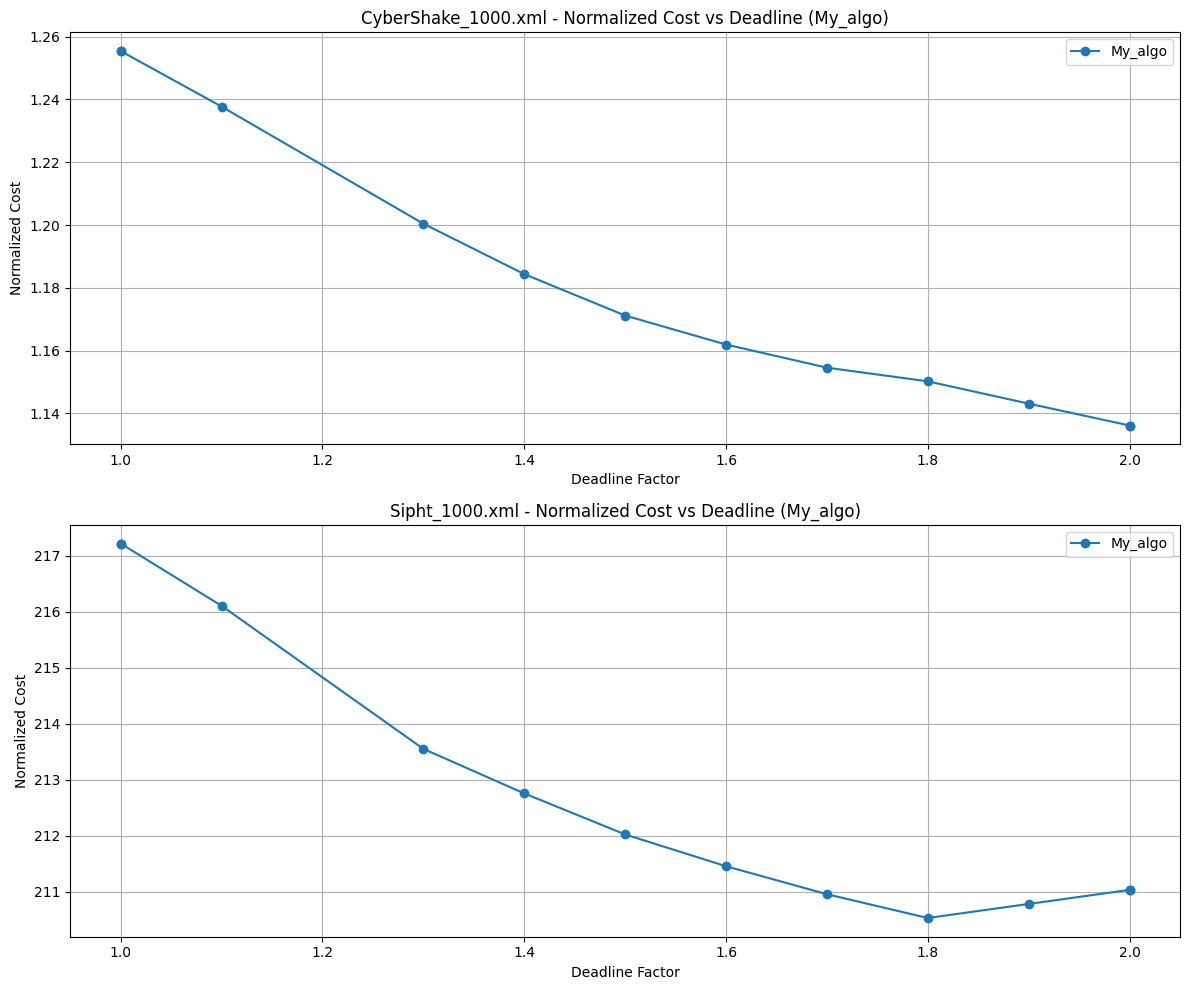

In [22]:
# Read the dataset
df_my = pd.read_csv("workflow-wise-costs-999_1000-Legrange_v2.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {"Montage_100.xml","Epigenomics_100.xml"}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Deadline")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / 1

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Deadline"], frac=0.5)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline (My_algo)")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

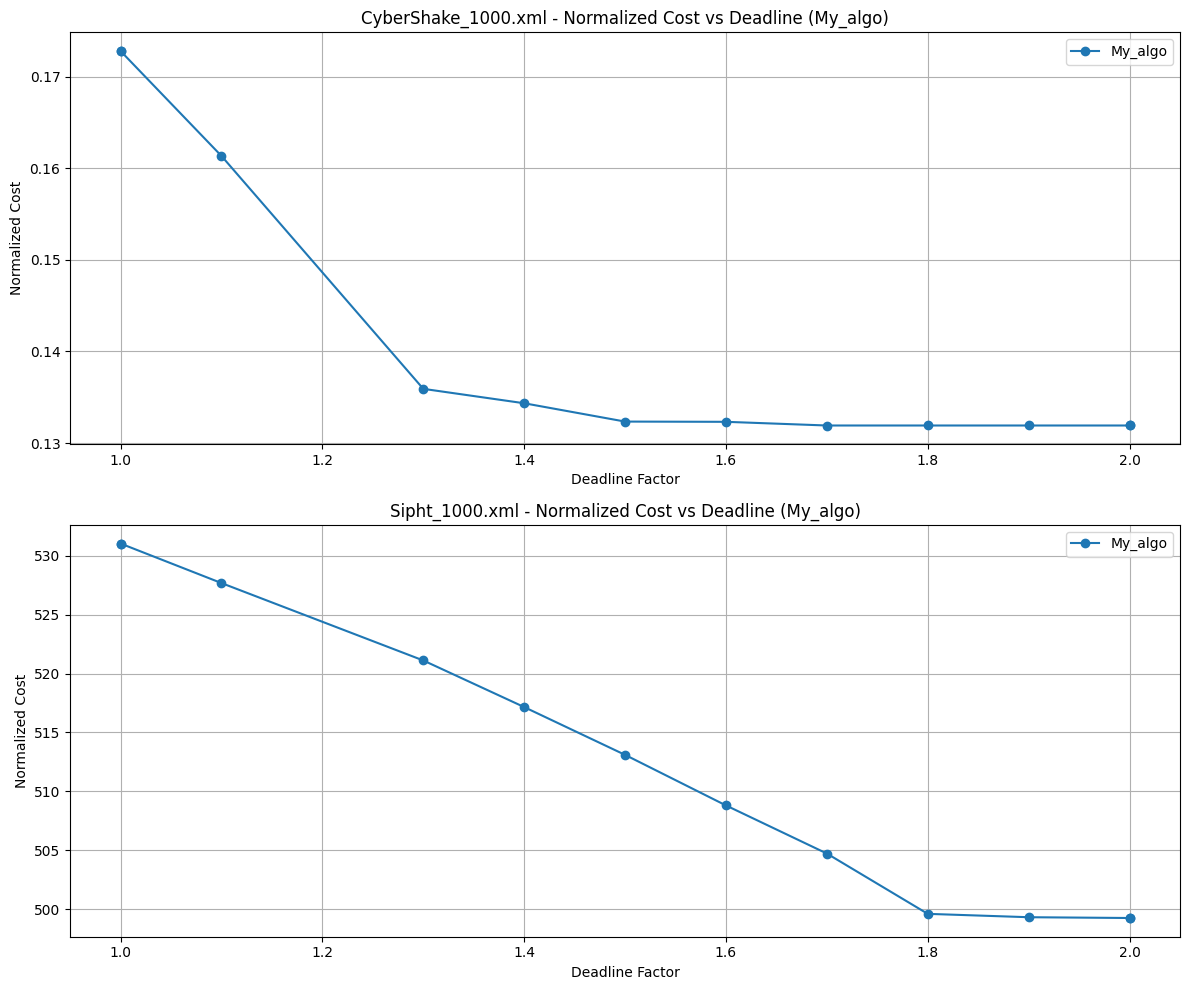

In [26]:
# Read the dataset
df_my = pd.read_csv("workflow-wise-costs-700_1000-Legrange_v2.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {"Montage_1000.xml"}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Deadline")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / 1

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Deadline"], frac=0.5)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline (My_algo)")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

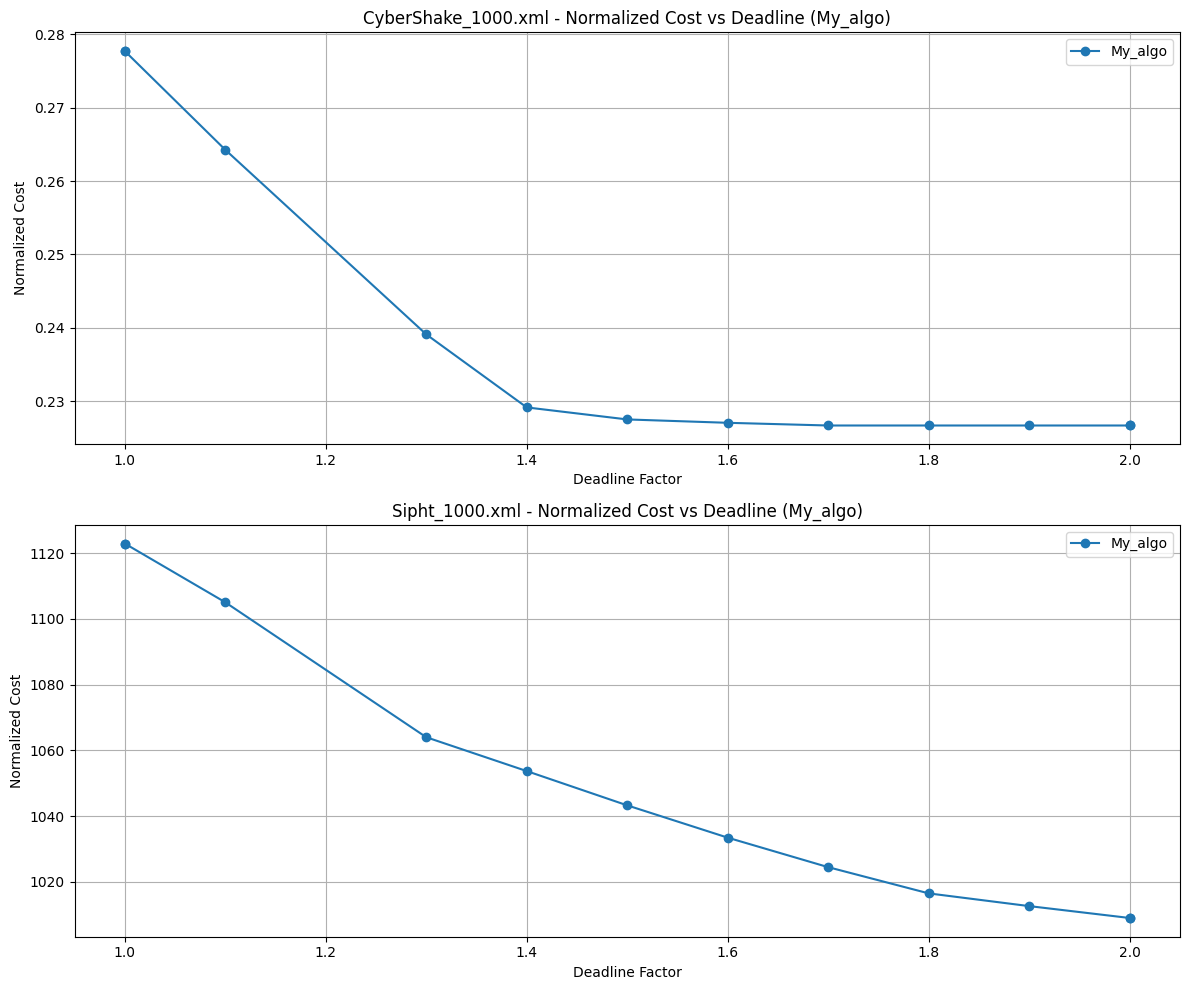

In [27]:
# Read the dataset
df_my = pd.read_csv("workflow-wise-costs-700_1000-Legrange_v2.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {"Montage_1000.xml"}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Deadline")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / 1

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Deadline"], frac=0.5)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline (My_algo)")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

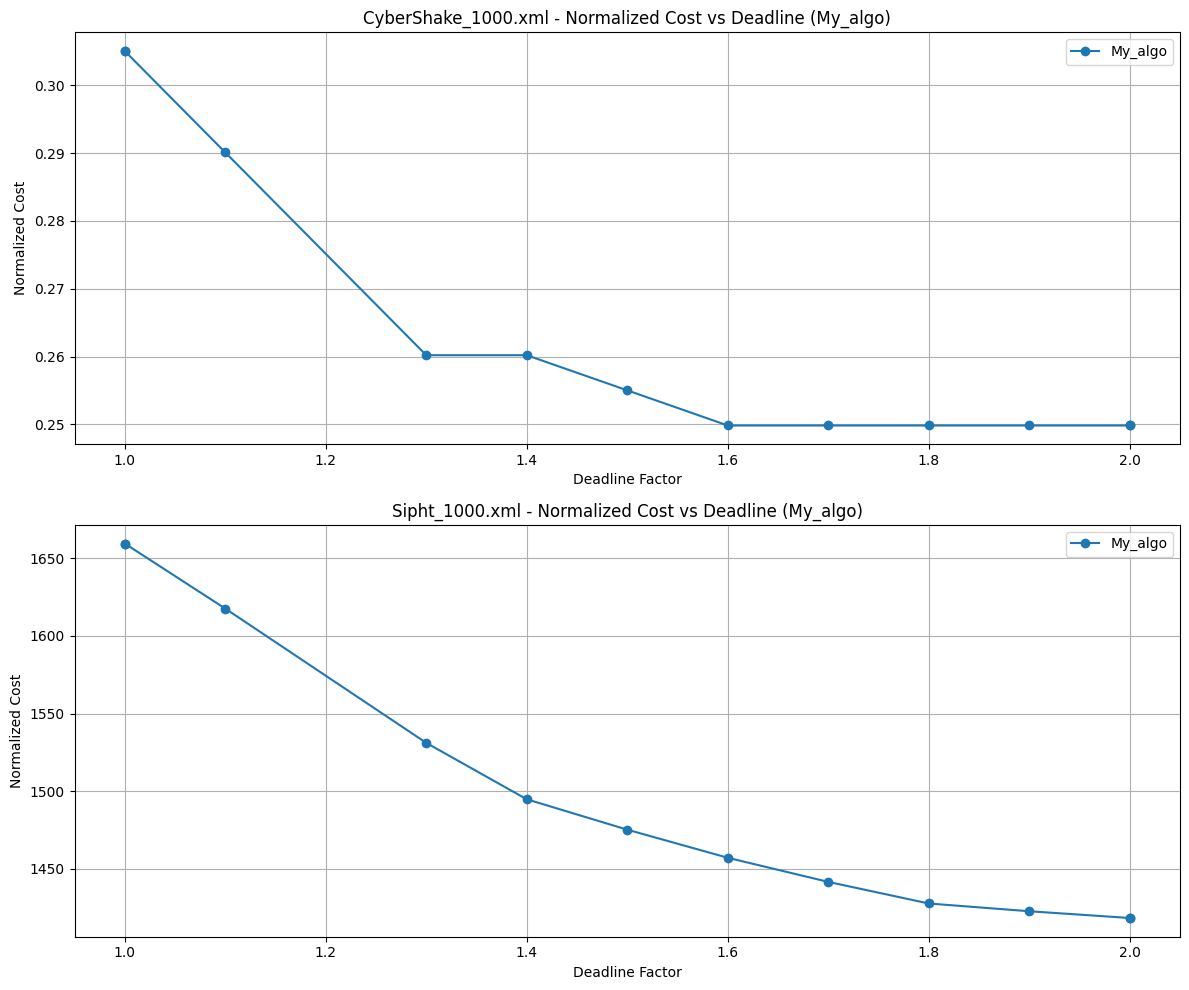

In [28]:
# Read the dataset
df_my = pd.read_csv("workflow-wise-costs-700_1000-Legrange_v2.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {"Montage_1000.xml"}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Deadline")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / 1

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Deadline"], frac=0.5)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline (My_algo)")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

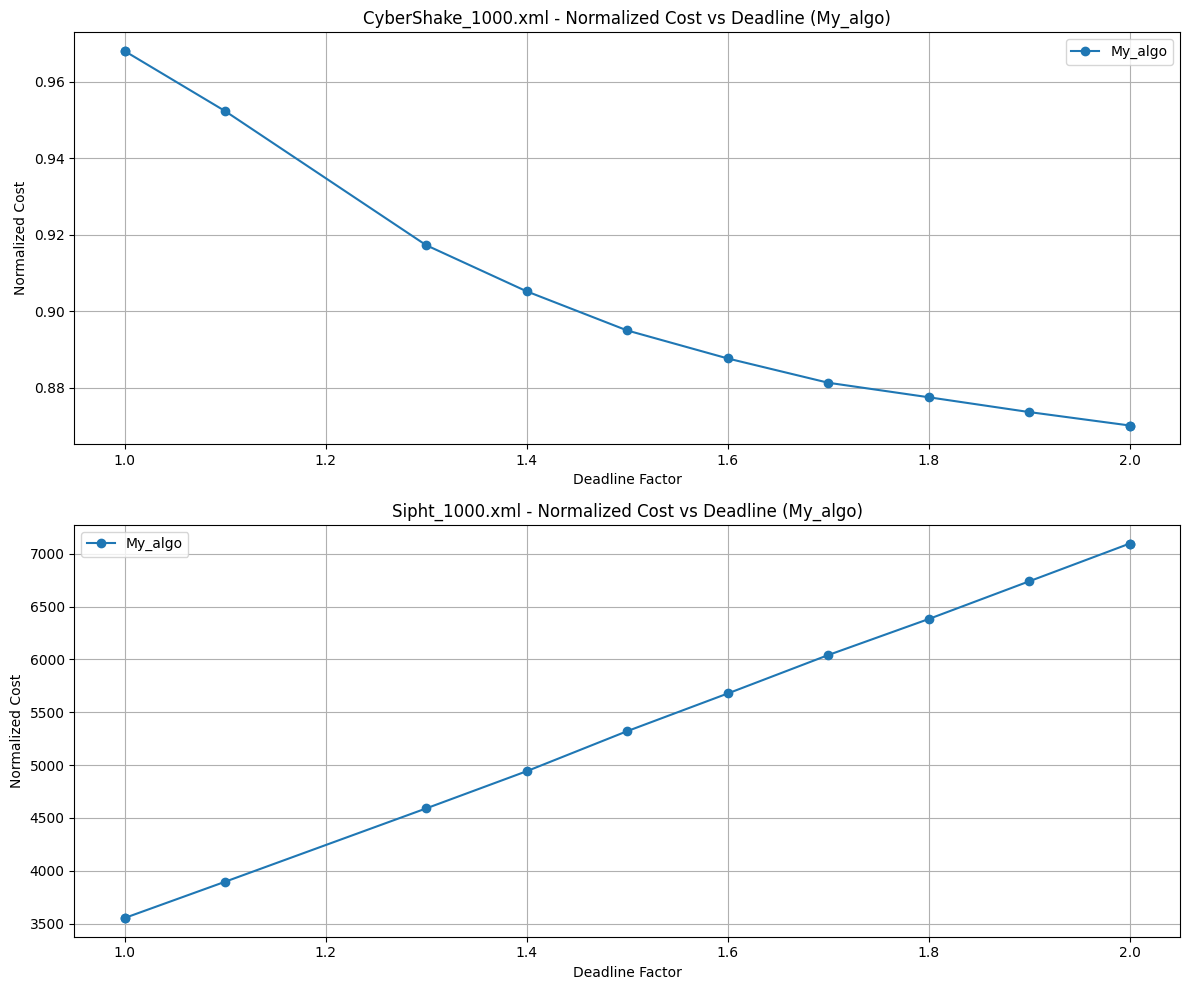

In [29]:
# Read the dataset
df_my = pd.read_csv("workflow-wise-costs-700_1000-Legrange_v2.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {"Montage_1000.xml"}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Deadline")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / 1

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Deadline"], frac=0.5)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline (My_algo)")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

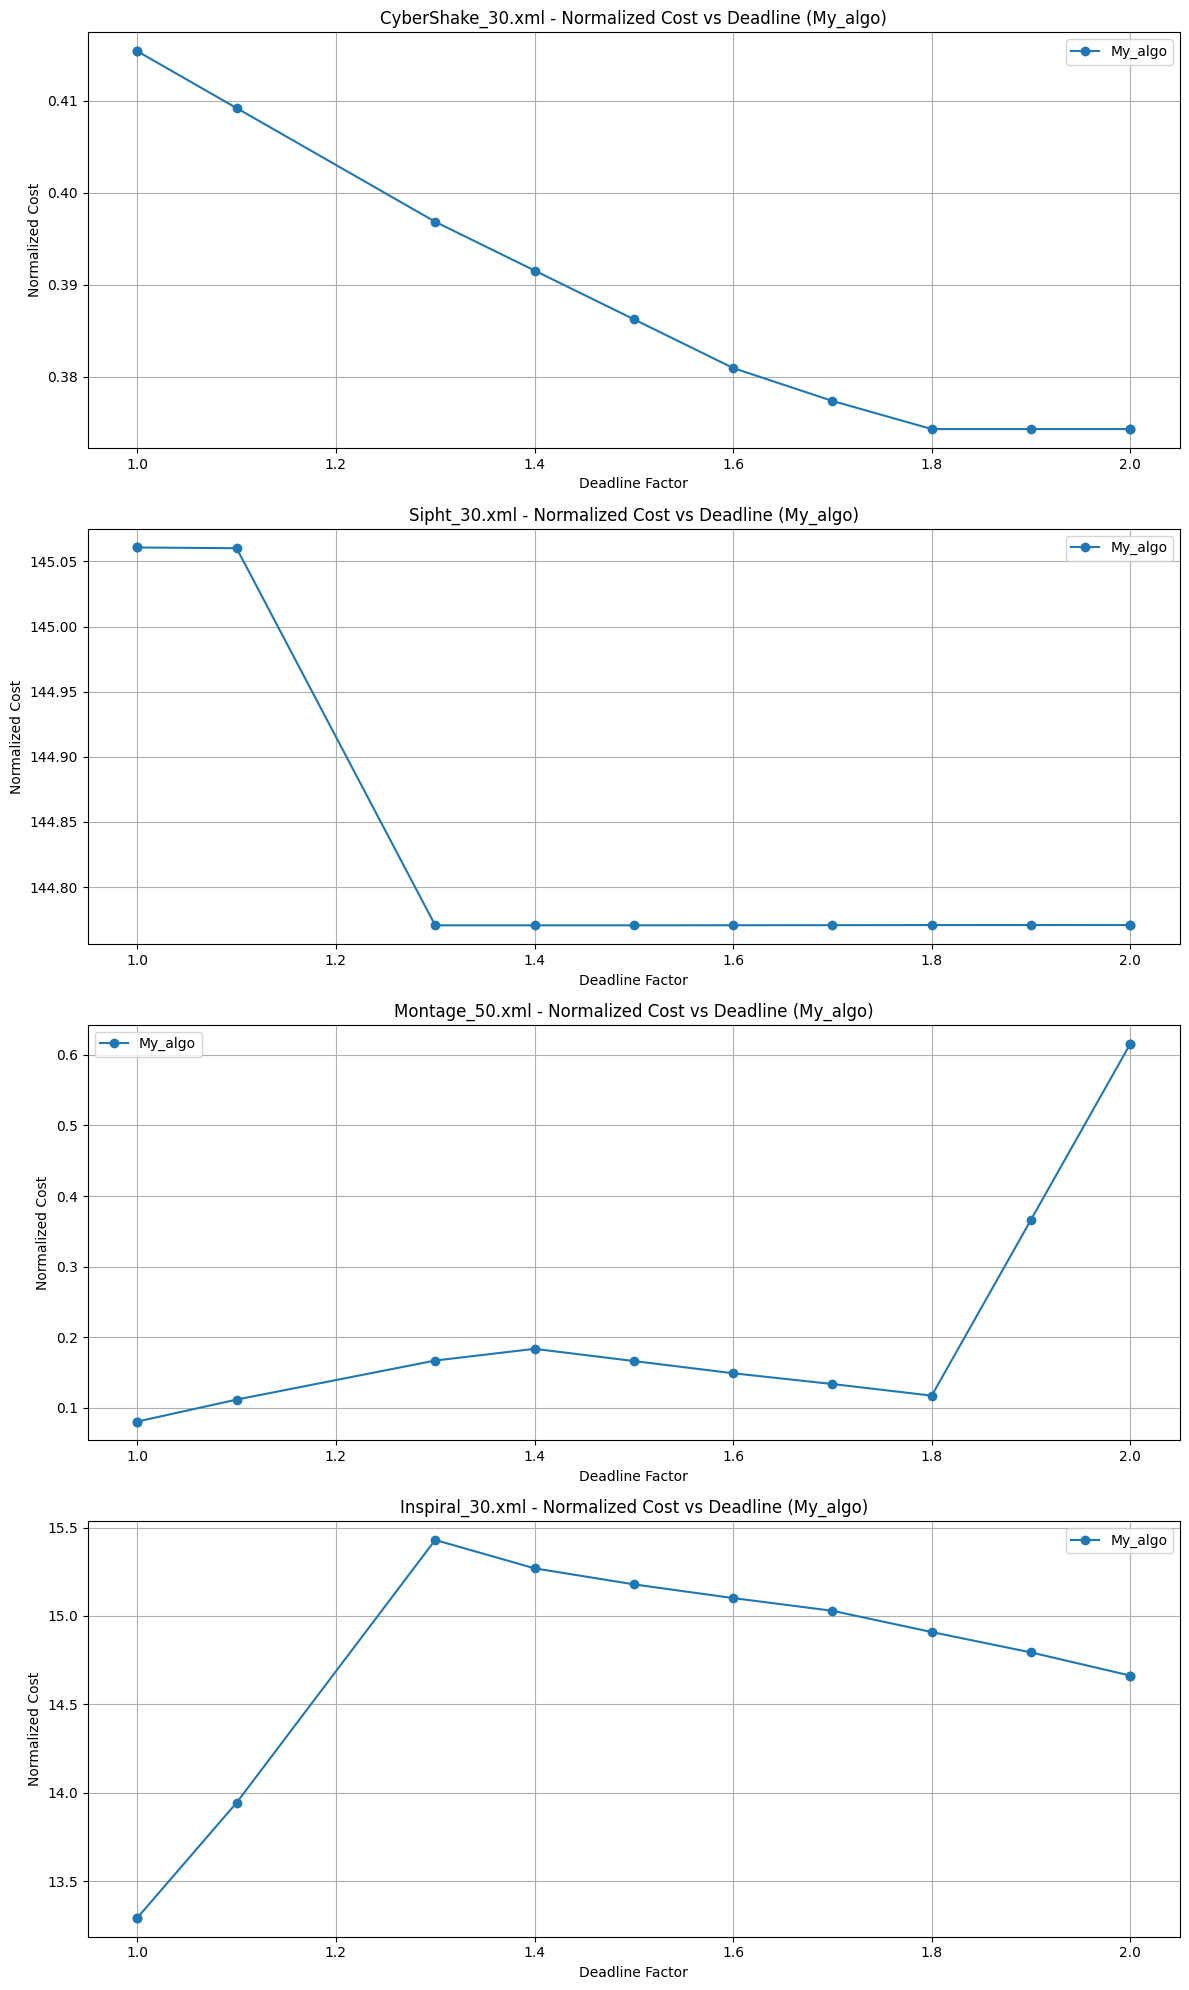

In [30]:
# Read the dataset
df_my = pd.read_csv("workflow-wise-costs-999_30-Legrange_v2.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {"Montage_1000.xml"}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Deadline")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / 1

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Deadline"], frac=0.5)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline (My_algo)")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

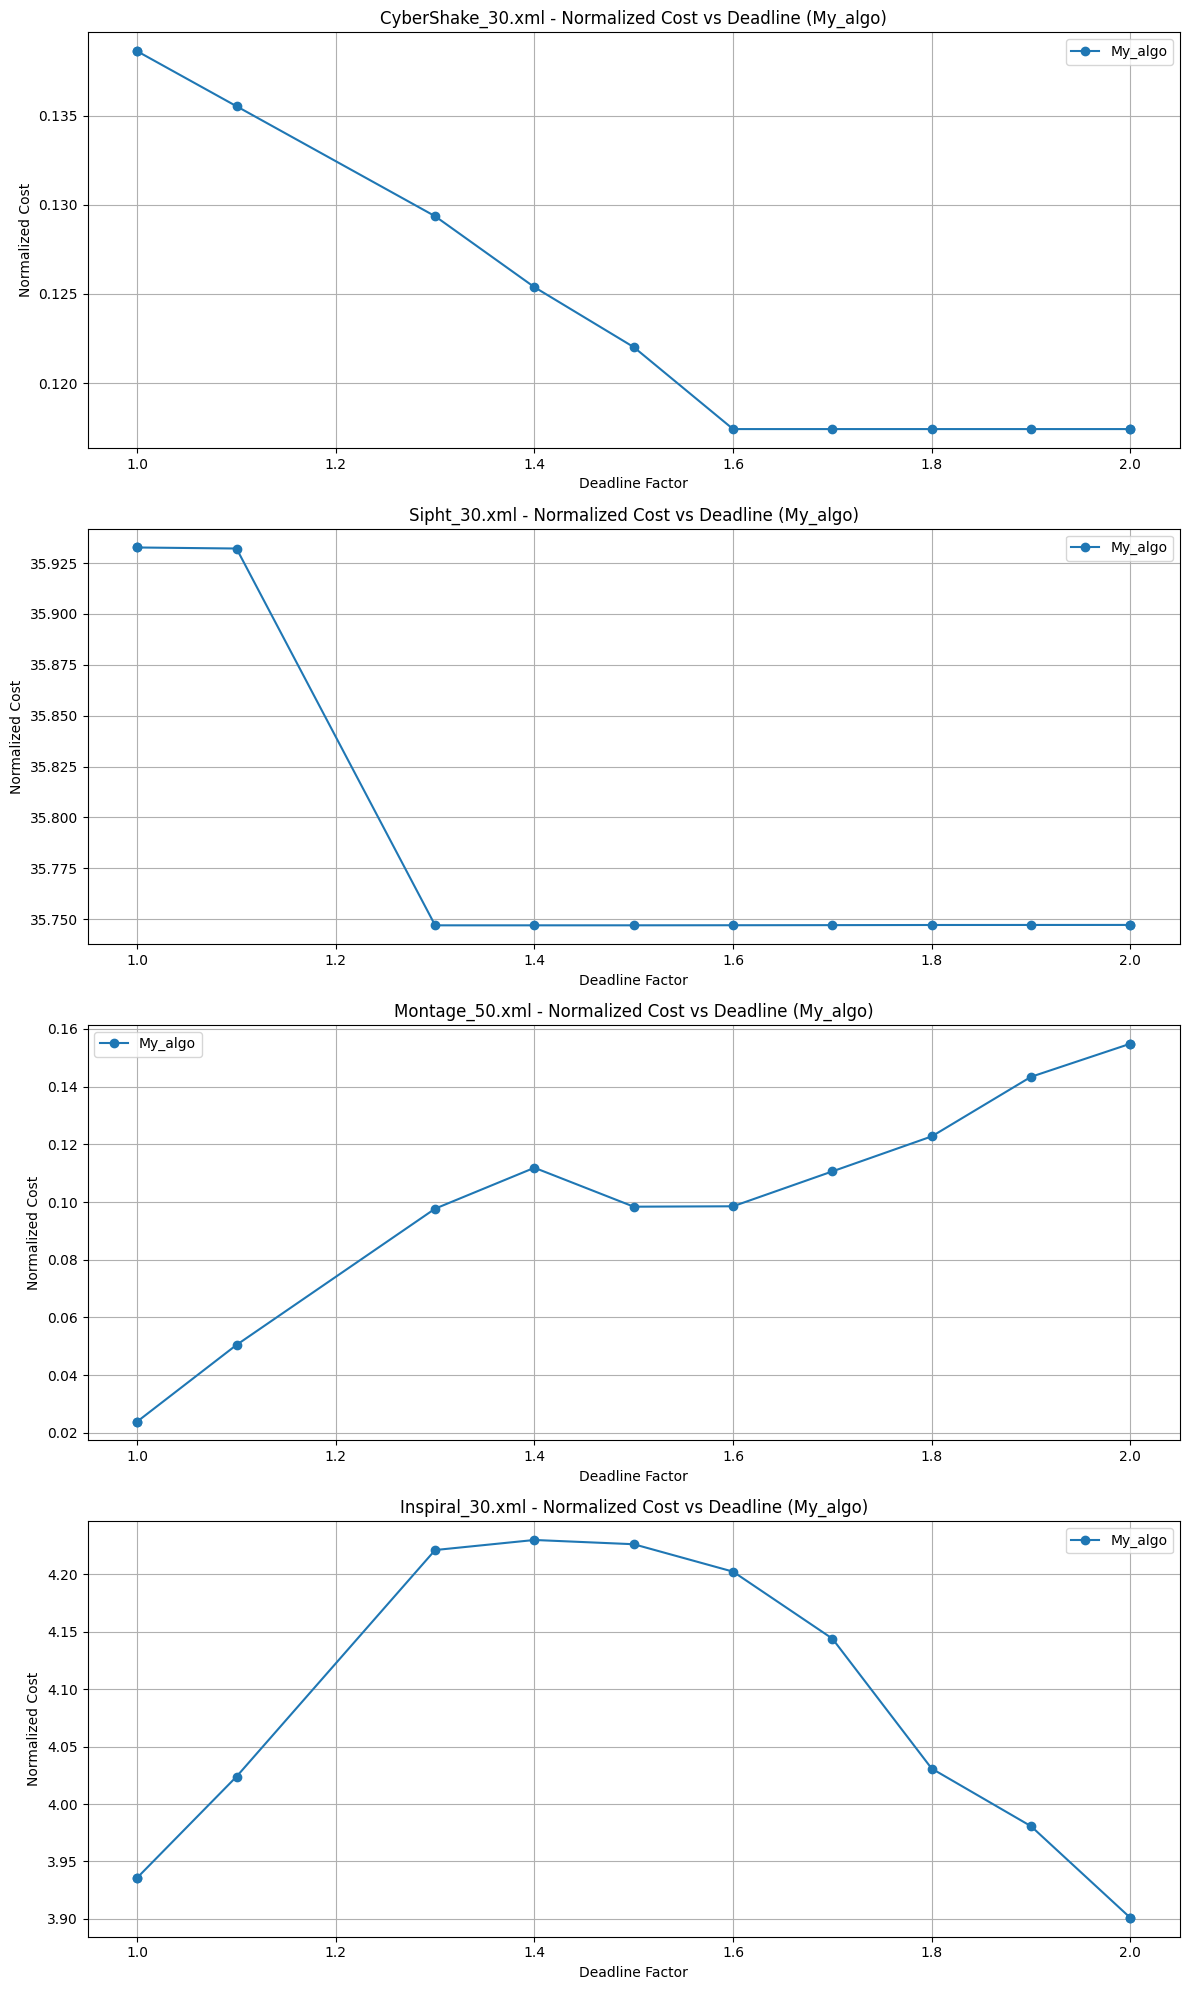

In [32]:
# Read the dataset
df_my = pd.read_csv("workflow-wise-costs-955_30-Legrange_v2.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {"Montage_1000.xml"}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Deadline")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / 1

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Deadline"], frac=0.5)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline (My_algo)")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

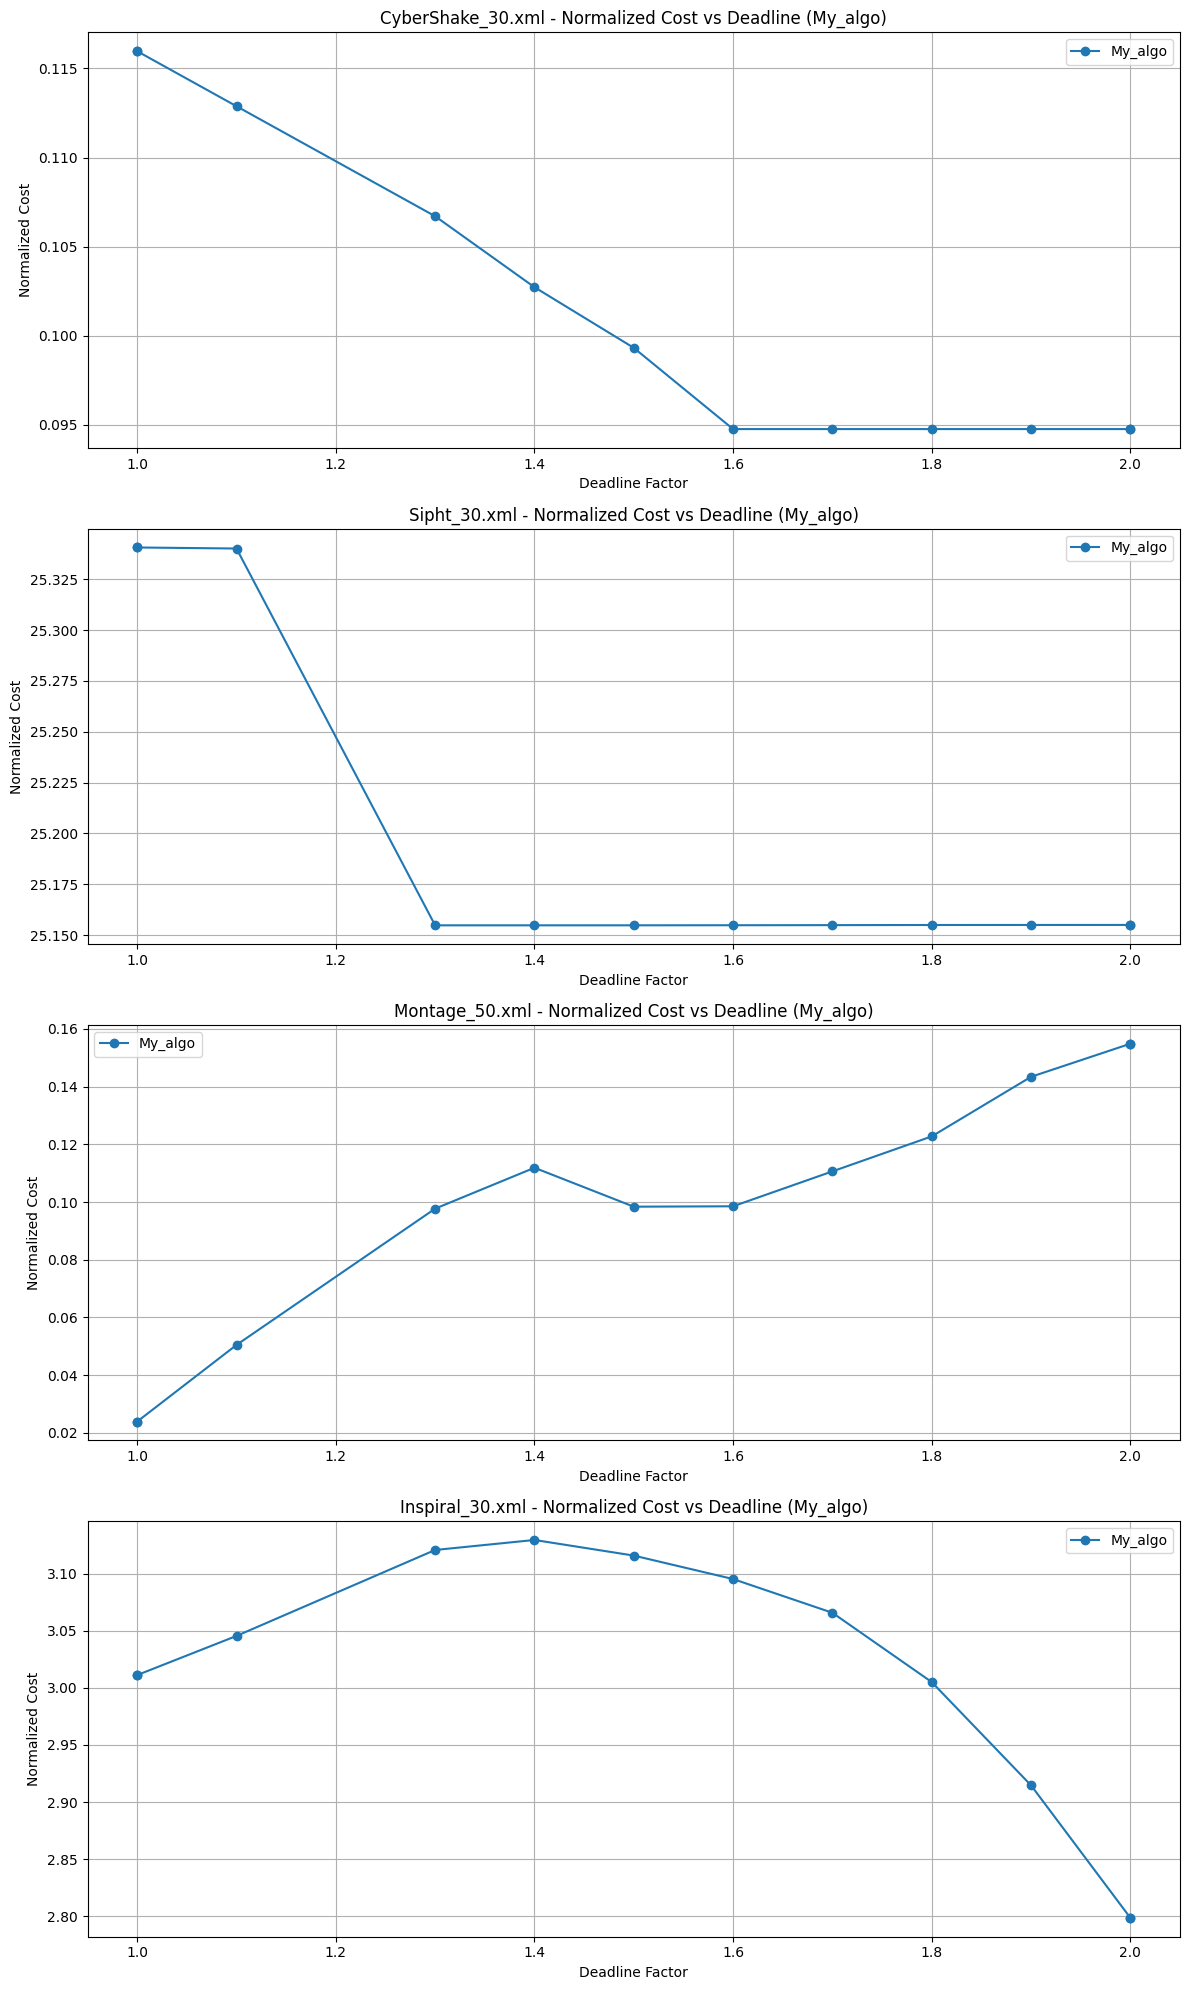

In [33]:
# Read the dataset
df_my = pd.read_csv("workflow-wise-costs-900_30-Legrange_v2.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {"Montage_1000.xml"}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Deadline")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / 1

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Deadline"], frac=0.5)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline (My_algo)")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

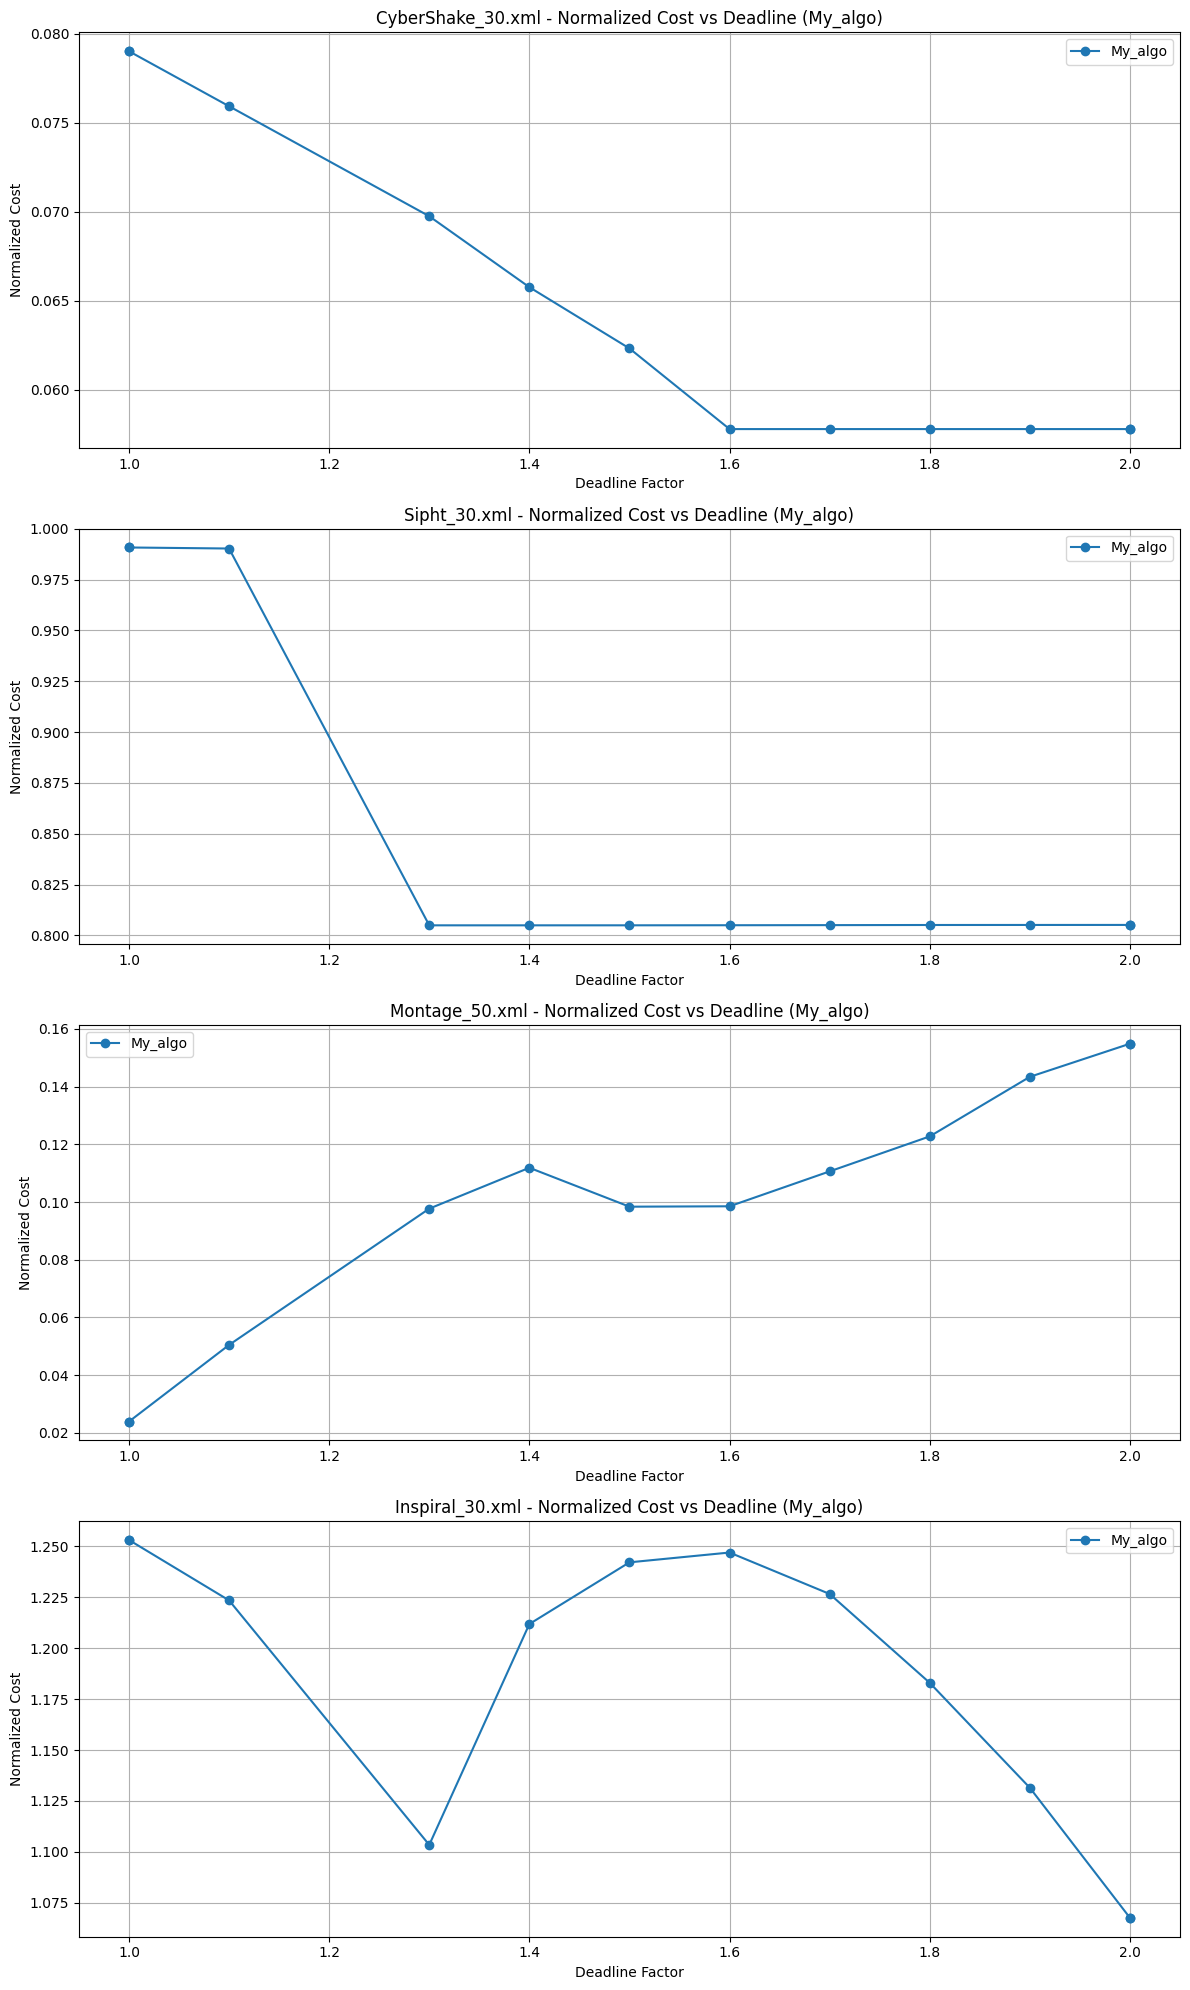

In [34]:
# Read the dataset
df_my = pd.read_csv("workflow-wise-costs-900_30-Legrange_v3.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {"Montage_1000.xml"}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Deadline")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / 1

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Deadline"], frac=0.5)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline (My_algo)")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

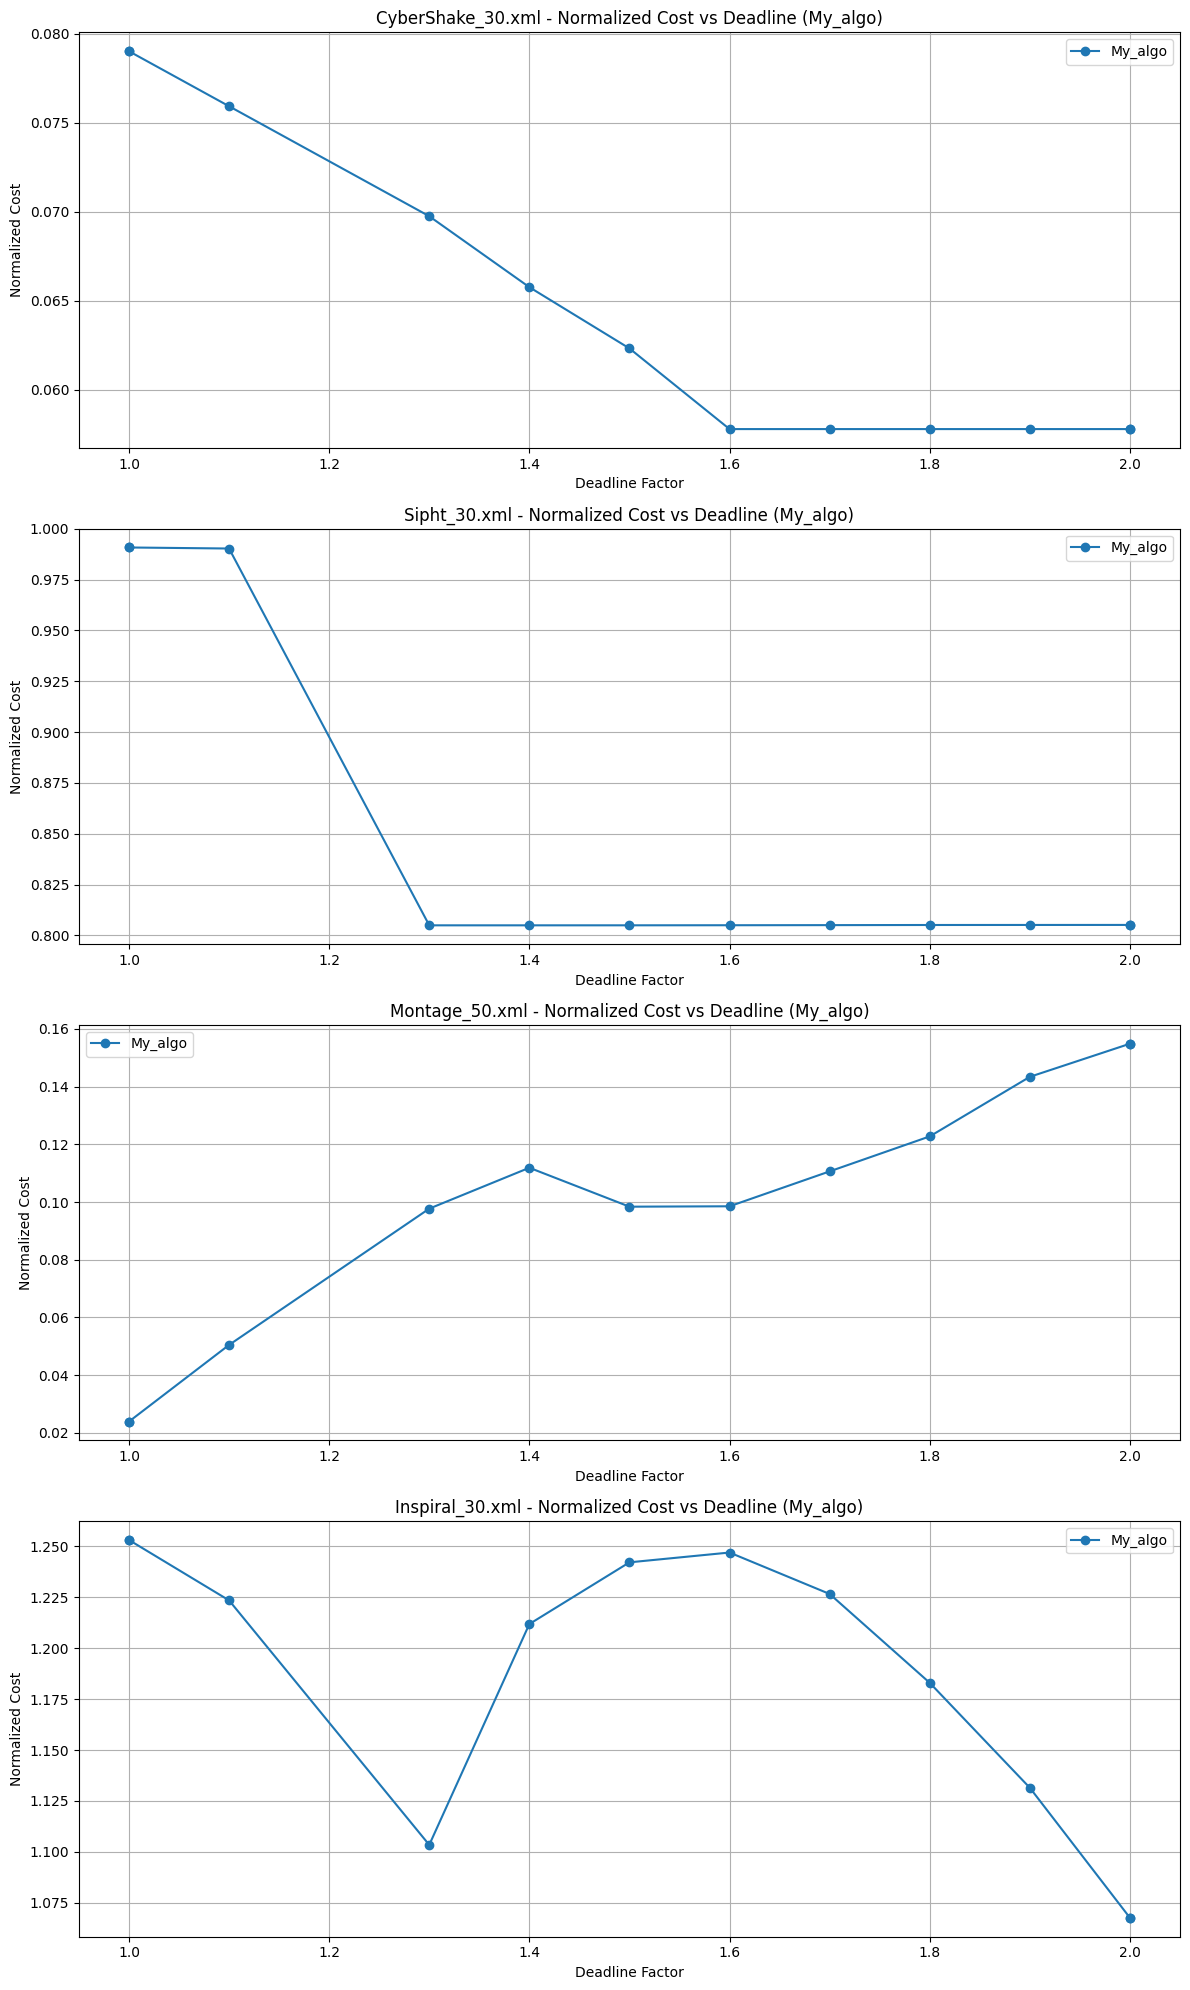

In [35]:
# Read the dataset
df_my = pd.read_csv("workflow-wise-costs-955_30-Legrange_v3.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {"Montage_1000.xml"}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Deadline")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / 1

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Deadline"], frac=0.5)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline (My_algo)")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

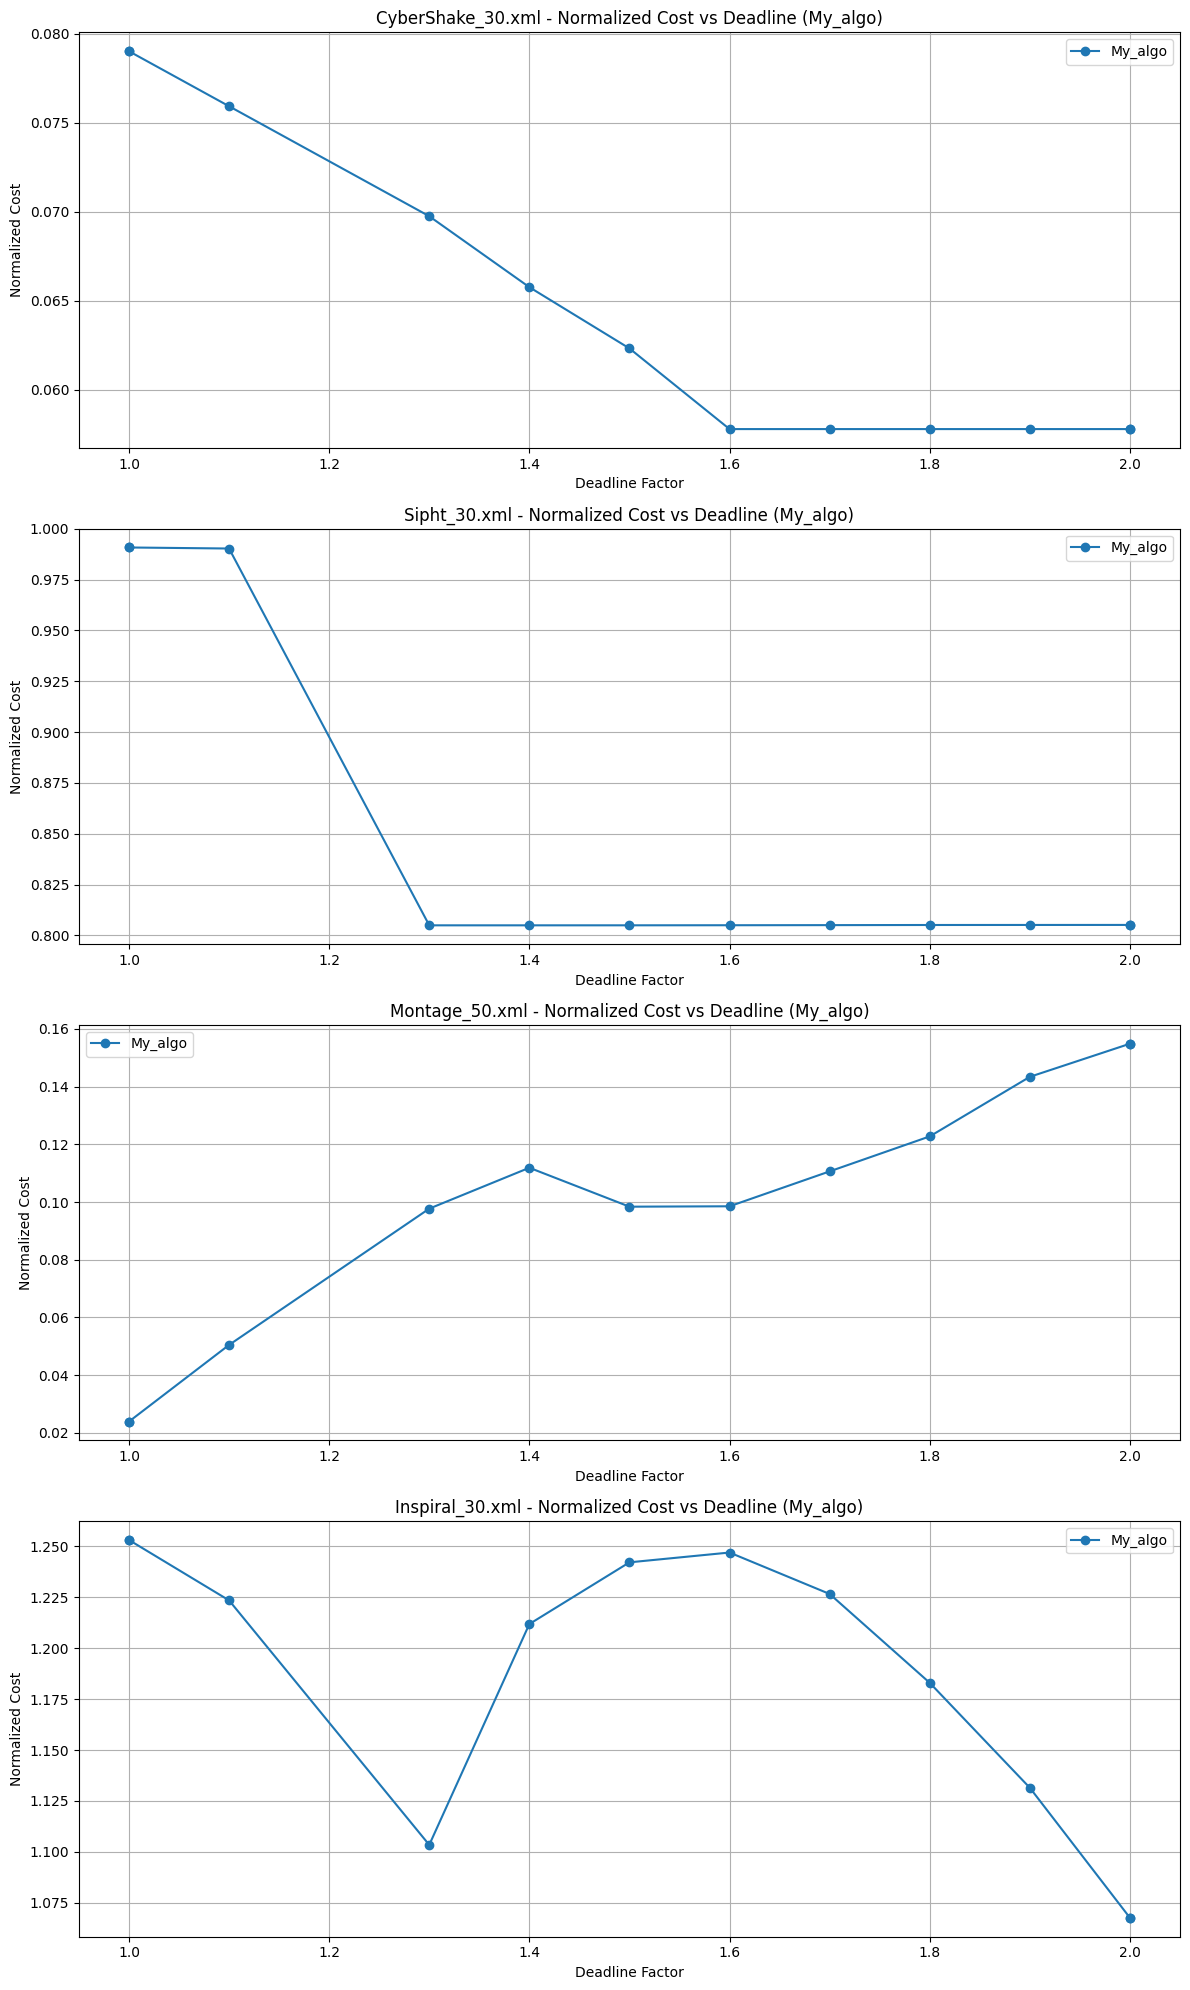

In [36]:
# Read the dataset
df_my = pd.read_csv("workflow-wise-costs-999_30-Legrange_v3.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {"Montage_1000.xml"}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Deadline")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / 1

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Deadline"], frac=0.5)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline (My_algo)")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

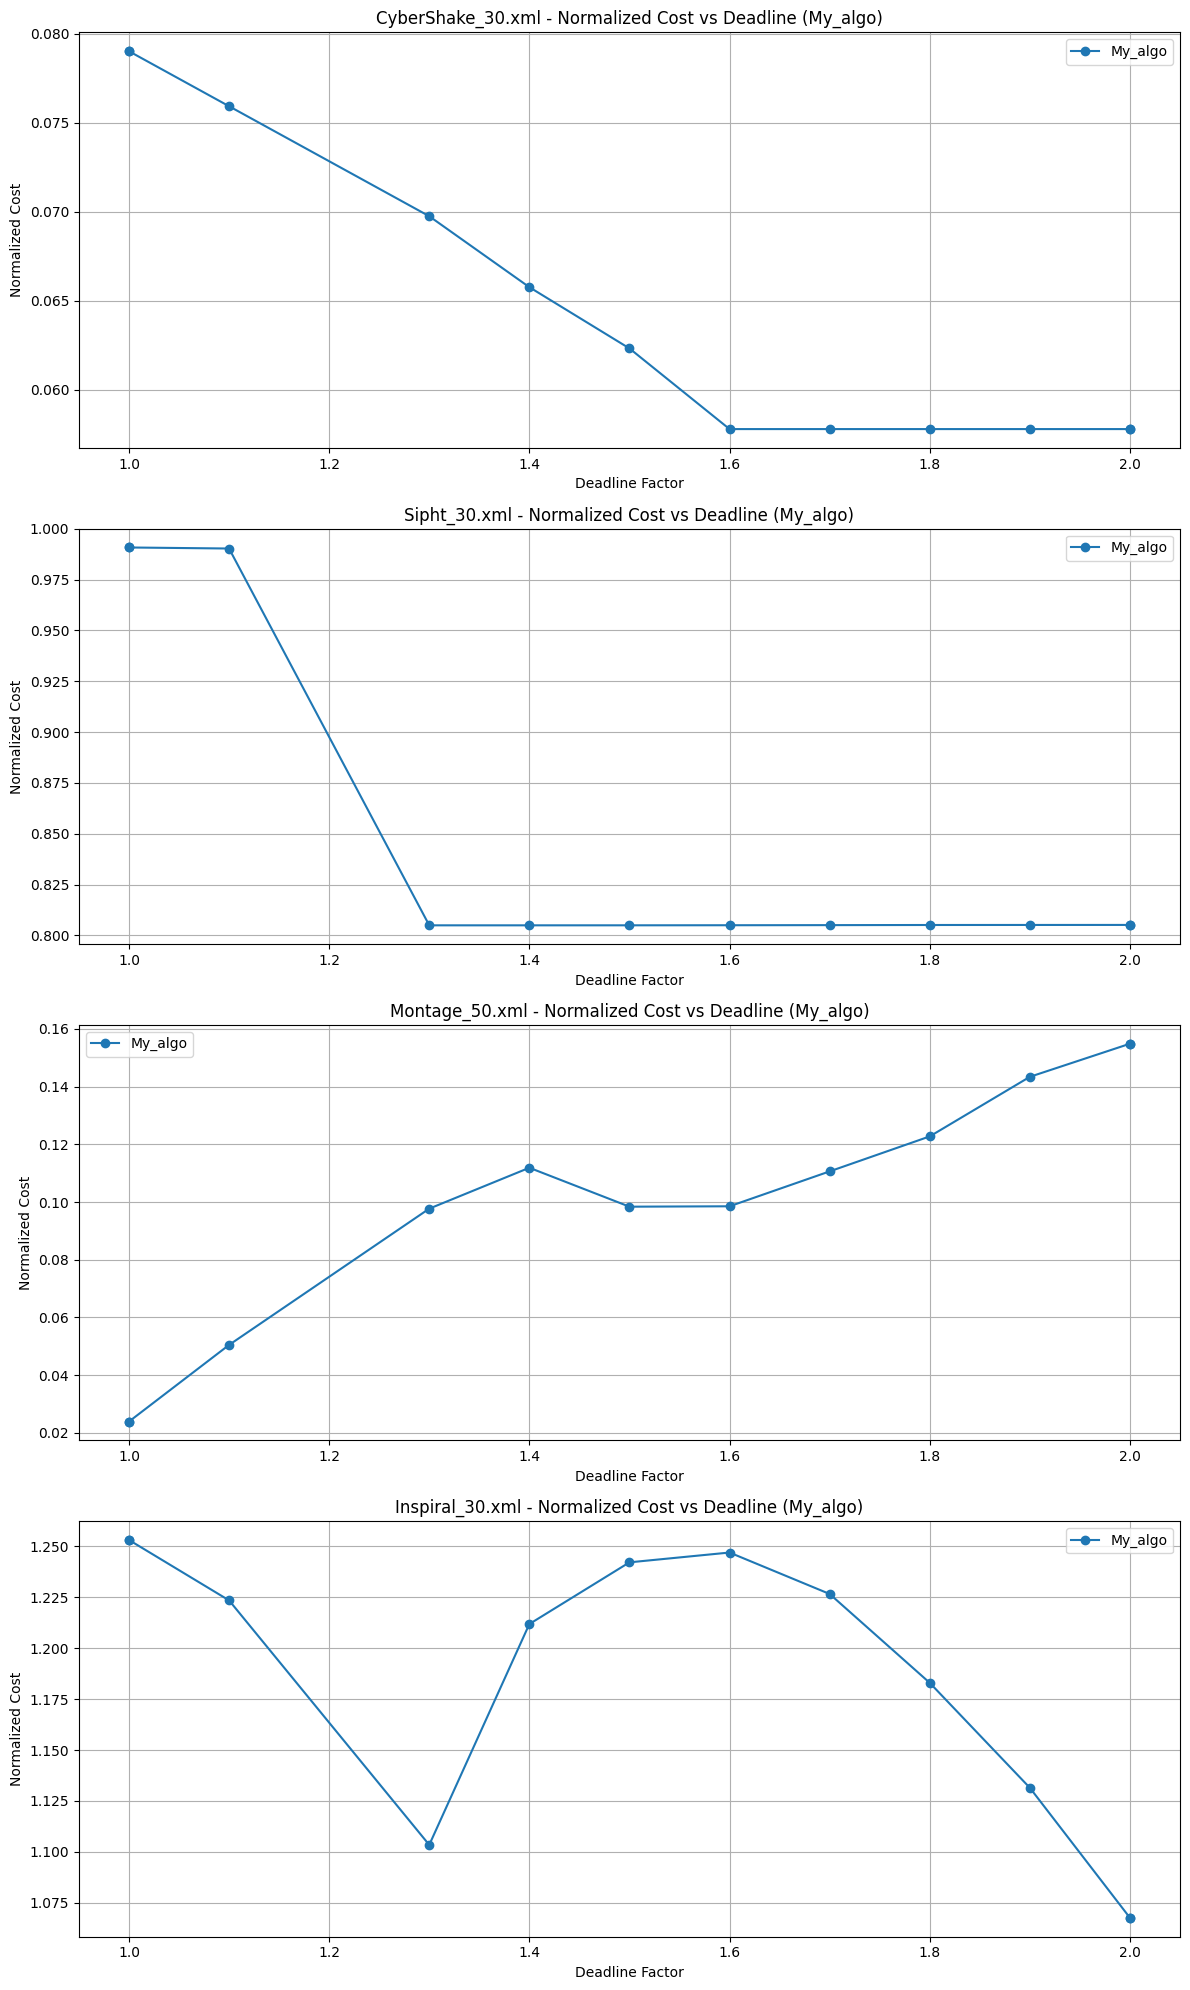

In [37]:
# Read the dataset
df_my = pd.read_csv("workflow-wise-costs-800_30-Legrange_v3.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {"Montage_1000.xml"}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Deadline")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / 1

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Deadline"], frac=0.5)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline (My_algo)")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

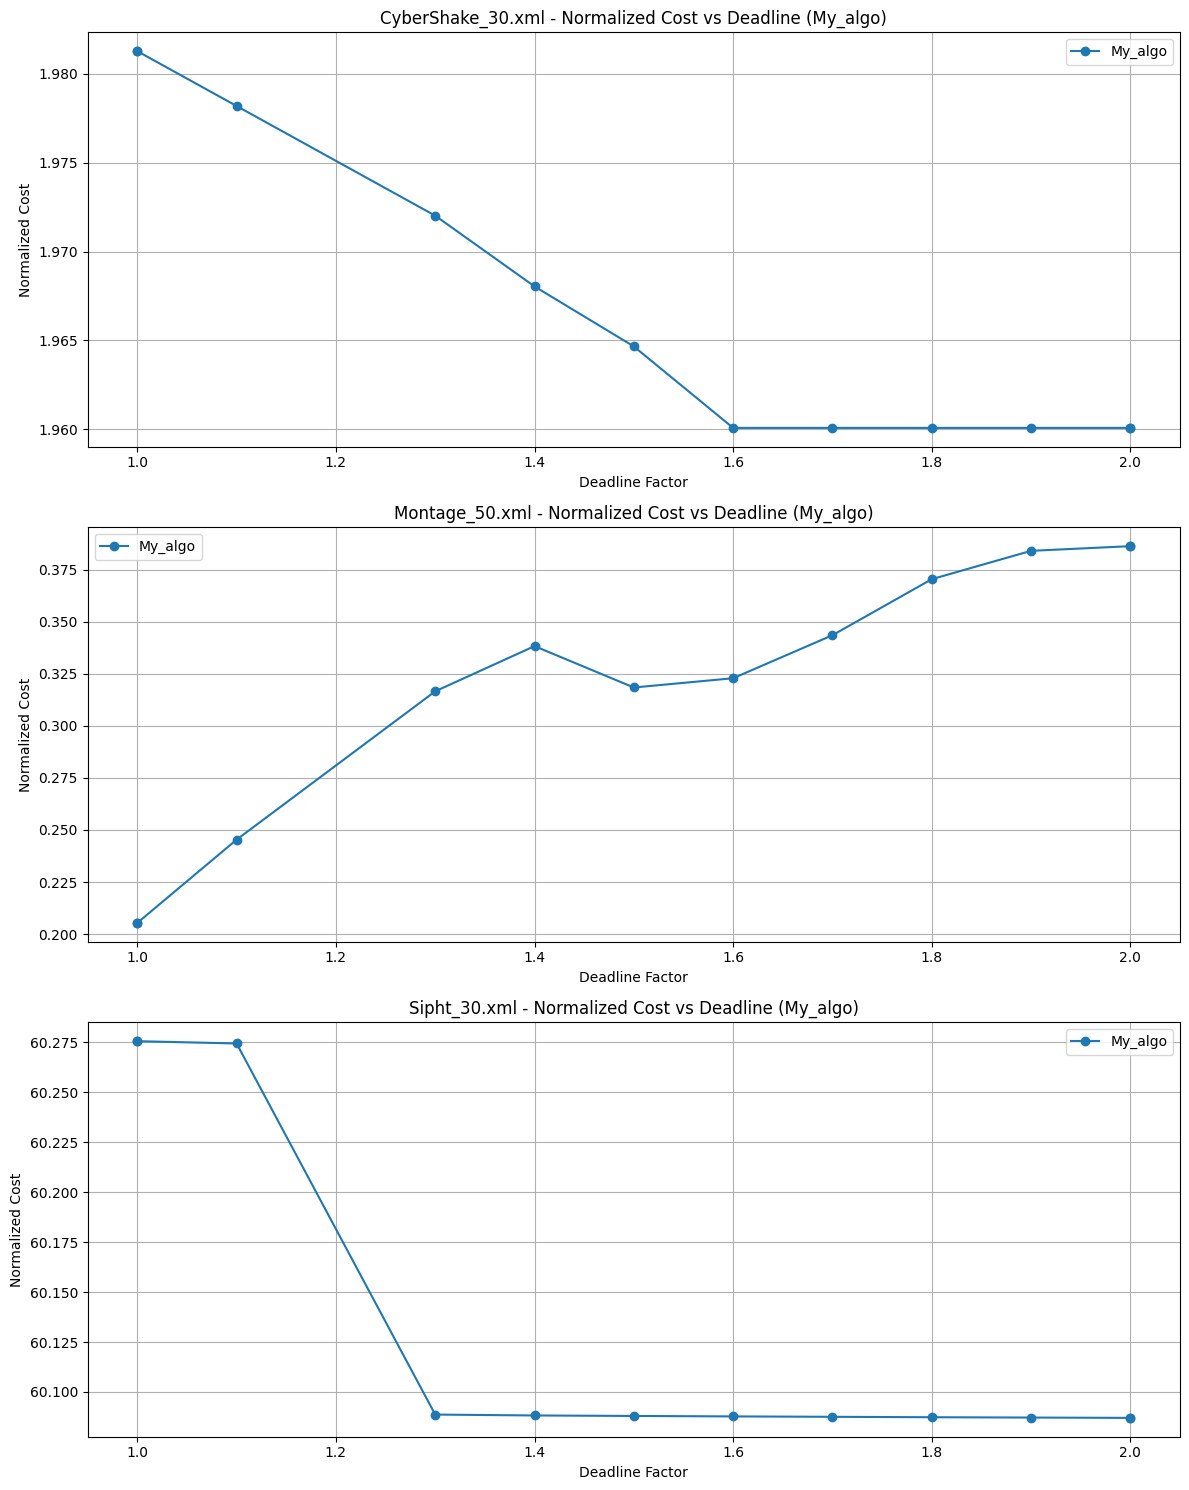

In [48]:
# Read the dataset
df_my = pd.read_csv("workflow-wise-costs-999_30-Legrange_v4.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Deadline")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / 1

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Deadline"], frac=0.5)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline (My_algo)")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

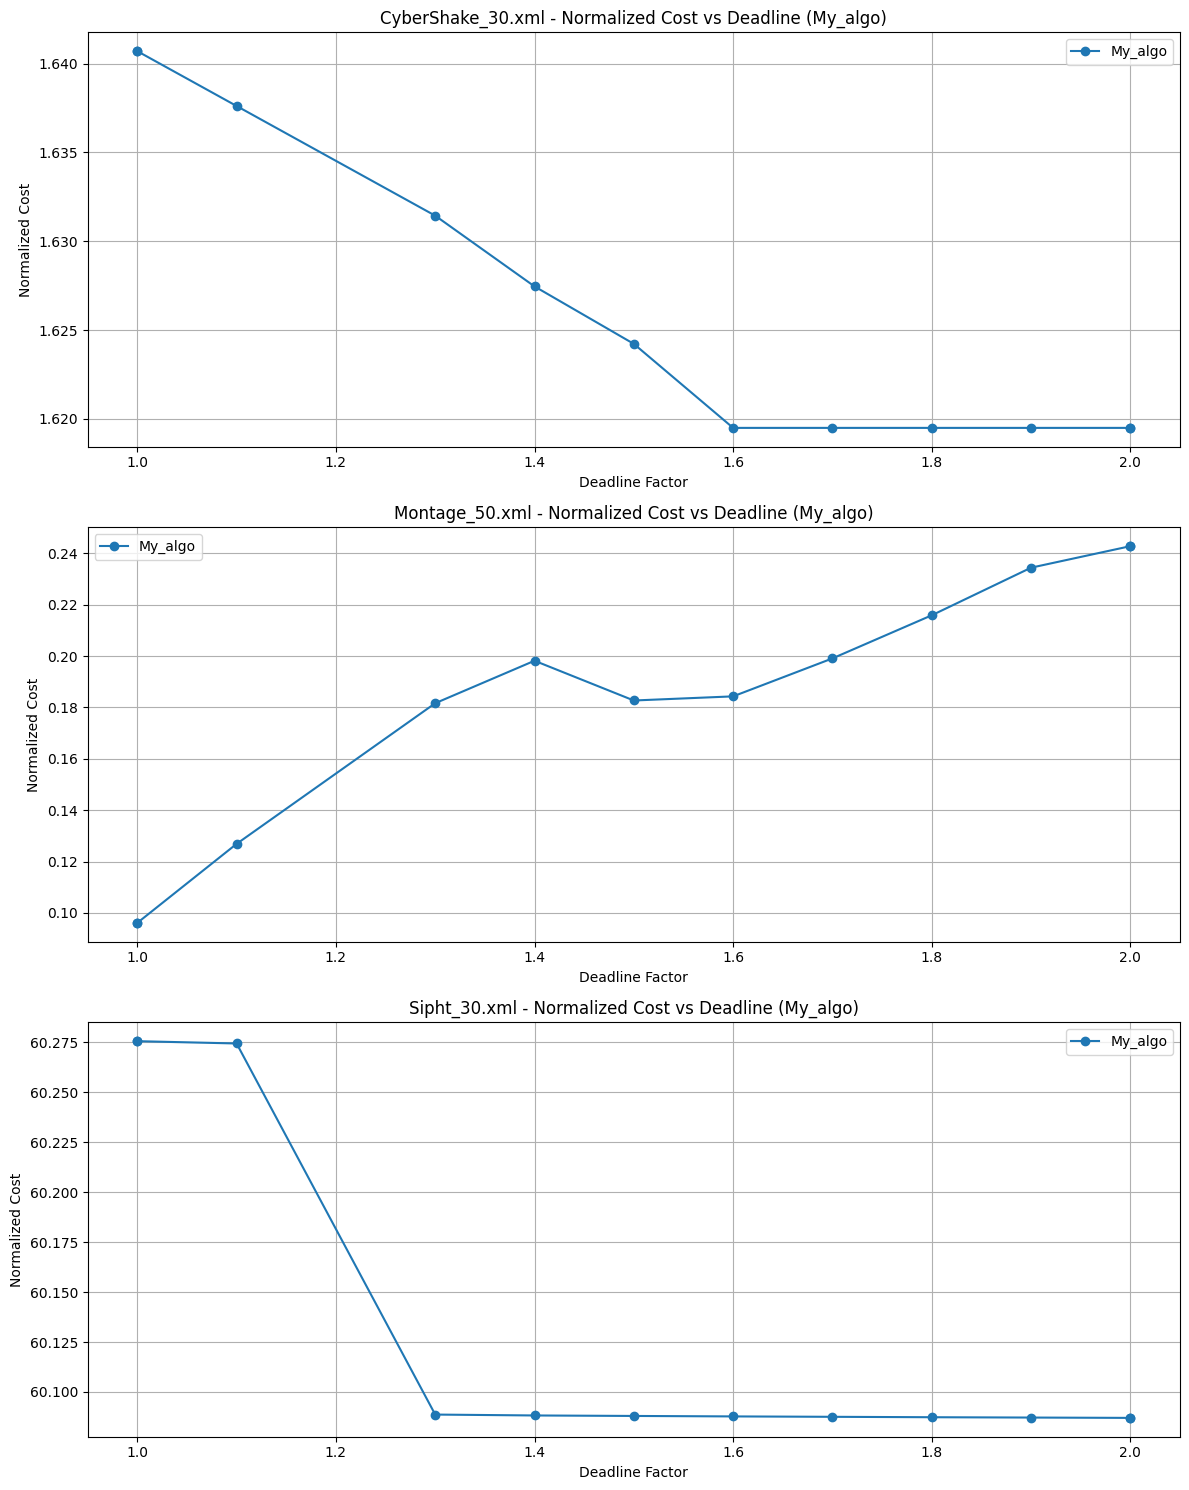

In [49]:
# Read the dataset
df_my = pd.read_csv("workflow-wise-costs-955_30-Legrange_v4.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Deadline")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / 1

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Deadline"], frac=0.5)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline (My_algo)")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

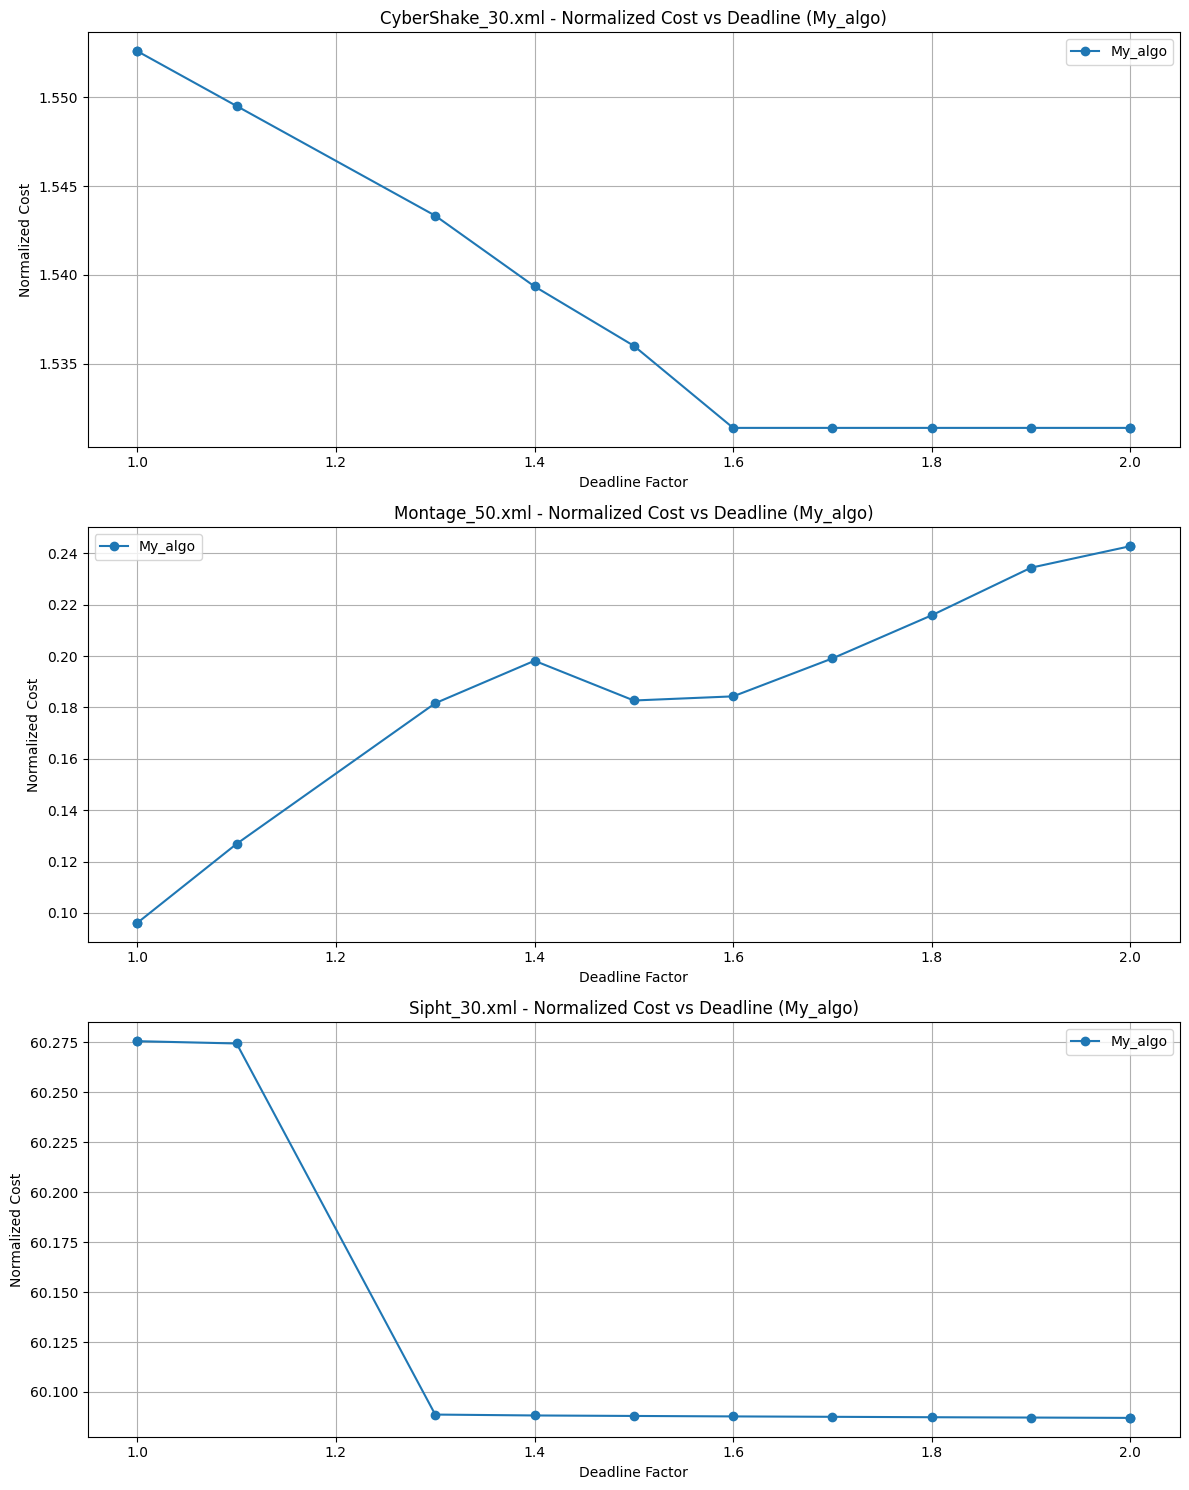

In [50]:
# Read the dataset
df_my = pd.read_csv("workflow-wise-costs-900_30-Legrange_v4.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Deadline")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / 1

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Deadline"], frac=0.5)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline (My_algo)")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
import re

def extract_storage_gb(val):
    if isinstance(val, str):
        if 'EBS only' in val:
            return 0
        match = re.search(r'(\d+)\s*GB', val)
        if match:
            return int(match.group(1))
    return 0  # fallback if malformed

# Load the CSV
df = pd.read_csv("cleaned_vm_data.csv")

# Apply cleaning
df['Instance Storage'] = df['Instance Storage'].apply(extract_storage_gb)

# Save to new CSV
df.to_csv("cleaned_vm_data_storage.csv", index=False)

